# Проект. Аналитика сервиса Яндекс Афиша

- Автор: Костюк Юлия Исфандияровна
- Дата: 26.05.2026

## Введение

Сервис «Яндекс Афиша» предоставляет пользователям возможность находить мероприятия и покупать билеты. В ноябре 2024 года команда продукта зафиксировала разнонаправленную динамику продаж: одни события демонстрируют рост, другие — снижение.

Потенциальные причины:

- сезонное изменение предпочтений пользователей;
- смена аудитории;
- разная популярность категорий мероприятий;
- разница в поведении пользователей мобильных устройств и стационарных компьютеров.

В данном проекте проводится исследовательский анализ данных (EDA) в Python и проверка гипотез.
Цель — выявить ключевые изменения в пользовательских предпочтениях, проанализировать структуру выручки и проверить статистические гипотезы о различиях между мобильными и десктопными пользователями.

**Цели исследования:**

1. Изучить динамику продаж билетов осенью 2024 года.
2. Выявить категории мероприятий, организаторов и площадок, показавших рост или снижение популярности.
3. Проверить гипотезу о различиях в поведении пользователей мобильных и стационарных устройств.
4. Подготовить аналитические выводы и инсайты для команды продукта.

**Задачи исследования:**

1. Загрузка данных и знакомство с ними

- Загрузить данные о заказах, мероприятиях и курсах валют.
- Оценить объём, структуру, пропуски и соответствие описанию.

2. Предобработка данных

- Обработать пропуски (кроме `days_since_prev`).
- Проверить и нормализовать категориальные переменные.
- Проанализировать распределение `revenue` и `tickets_count`, устранить выбросы по 99-му процентилю отдельно для рублей и тенге.
- Удалить явные и неявные дубликаты.
- Преобразовать типы данных (даты, категории).
- Создать новые признаки:
  · `revenue_rub` — выручка в рублях с учётом курса тенге;
  · `one_ticket_revenue_rub` — выручка на один билет;
  · `month` — месяц заказа;
  · `season` — сезон (лето, осень, зима, весна).

3. Исследовательский анализ данных (EDA)

- Анализ распределения заказов по сегментам и их сезонные изменения.
    * Изучить изменение пользовательской активности или пользовательского интереса в связи с сезонностью.
    * Проанализировать динамику по таким разрезам:
        + тип мероприятия `event_type_main`;
        + тип устройства `device_type_canonical`;
        + категория мероприятий по возрастному рейтингу `age_limit`.
- Осенняя активность пользователей
    * Изучите активность пользователей осенью 2024 года.
    * Проанализировать динамику изменений по дням для:
        + общего числа заказов;
        + количества активных пользователей DAU;
        + среднего числа заказов на одного пользователя;
        + средней стоимости одного билета.

- Популярные события и партнёры
    * Посмотреть, как события распределены по регионам и партнёрам.
    * Для каждого региона посчитайте уникальное количество мероприятий и общее число заказов.
    * Для каждого билетного партнёра посчитайте общее число уникальных мероприятий, обработанных заказов и суммарную выручку с заказов билетов. Сделать акцент на наиболее активных партнёрах.

4. Проверка статистических гипотез на данных только за осенний период

- Проверить две гипотезы, которые предполагают большую активность пользователей мобильных устройств:
    * Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.
    * Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.
- Выбрать подходящий статистический критерий (t-тест или непараметрический аналог при нарушении нормальности).
- Сформулировать выводы о значимости различий.

5. Общий вывод и рекомендации

- Указать информацию о данных.
- Представить основные результаты анализа: какие мероприятия наиболее востребованы, как изменилась популярность мероприятий осенью, как изменилась стоимость среднего чека. Какую информацию можно получить после изучения пользовательской активности? Существуют ли среди регионов и партнёров явные лидеры по числу заказов и выручке с продажи билетов?
- Прокомментируйте результаты проверки гипотез.
- Дать рекомендации команде продукта.

## Содержимое проекта

* [Шаг 1. Загрузка данных и знакомство с ними](#1-bullet)
* [Шаг 2. Предобработка данных и подготовка их к исследованию](#2-bullet)
     - [2.1. Проверка данных на пропуски](#2.1-bullet)
     - [2.2. Объединение датафреймов](#2.2-bullet)
     - [2.3. Исследование значений в ключевых столбцах. Обработка ошибок](#2.3-bullet)
     - [2.4. Проверка явных и неявных дубликатов](#2.4-bullet)
     - [2.5. Преобразование типов данных](#2.5-bullet)
     - [2.6. Создание новых столбцов](#2.6-bullet)
* [Шаг 3. Исследовательский анализ данных](#3-bullet)
     - [3.1. Анализ распределения заказов по сегментам и их сезонные изменения](#3.1-bullet)
     - [3.2. Осенняя активность пользователей](#3.2-bullet)
     - [3.3. Популярные события и партнеры](#3.3-bullet)
* [Шаг 4. Статистический анализ данных](#4-bullet)
* [Шаг 5. Общий вывод и рекомендации](#5-bullet)
---

<a class="anchor" id="1-bullet"></a>
## Шаг 1. Знакомство с данными: загрузка и предобработка

Имеются два датасета `final_tickets_orders_df.csv` и `final_tickets_events_df.csv`

Первый датасет `final_tickets_orders_df.csv` включает информацию обо всех заказах билетов, совершённых с двух типов устройств — мобильных и стационарных. 
Описание данных:
- `order_id` — уникальный идентификатор заказа.
- `user_id` — уникальный идентификатор пользователя.
- `created_dt_msk` — дата создания заказа (московское время).
- `created_ts_msk` — дата и время создания заказа (московское время).
- `event_id` — идентификатор мероприятия из таблицы events.
- `cinema_circuit` — сеть кинотеатров. Если не применимо, то здесь будет значение 'нет'.
- `age_limit` — возрастное ограничение мероприятия.
- `currency_code` — валюта оплаты, например rub для российских рублей.
- `device_type_canonical` — тип устройства, с которого был оформлен заказ, например mobile для мобильных устройств, desktop для стационарных.
- `revenue` — выручка от заказа.
- `service_name` — название билетного оператора.
- `tickets_count` — количество купленных билетов.
- `total` — общая сумма заказа.
- `days_since_prev` — количество дней с предыдущей покупки для каждого пользователя. Если покупки не было, то данные содержат пропуск.

Второй датасет `final_tickets_events_df` содержит информацию о событиях, включая город и регион события, а также информацию о площадке проведения мероприятия. 
Датасет содержит такие поля:
- `event_id` — уникальный идентификатор мероприятия.
- `event_name`— название мероприятия. Аналог поля event_name_code из исходной базы данных.
- `event_type_description` — описание типа мероприятия.
- `event_type_main` — основной тип мероприятия: театральная постановка, концерт и так далее.
- `organizers` — организаторы мероприятия.
- `region_name` — название региона.
- `city_name` — название города.
- `city_id` — уникальный идентификатор города.
- `venue_id` — уникальный идентификатор площадки.
- `venue_name` — название площадки.
- `venue_address` — адрес площадки.

Выручка от заказов представлена в двух валютах — российских рублях и казахстанских тенге. Для удобства решения было бы корректно привести данные к одной валюте, например к российским рублям. Для этого имеется датасет `final_tickets_tenge_df.csv` с информацией о курсе тенге к российскому рублю за 2024 год. Значения в рублях представлено для 100 тенге. 
Датасет содержит такие поля:
- `nominal` — номинал (100 тенге).
- `data` — дата.
- `curs` — курс тенге к рублю.
- `cdx` — обозначение валюты (kzt).

### Вывод общей информации

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Импортируем библиотеку для проверки гипотез
from scipy import stats

In [2]:
# Выгружаем данные в переменные df_tickets_orders и df_tickets_events и df_tickets_tenge
df_tickets_orders = pd.read_csv('/datasets/final_tickets_orders_df.csv')
df_tickets_events = pd.read_csv('/datasets/final_tickets_events_df.csv')
df_tickets_tenge = pd.read_csv('/datasets/final_tickets_tenge_df.csv')

In [3]:
# Информация о датасете df_tickets_orders
df_tickets_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 290849 entries, 0 to 290848
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   order_id               290849 non-null  int64  
 1   user_id                290849 non-null  object 
 2   created_dt_msk         290849 non-null  object 
 3   created_ts_msk         290849 non-null  object 
 4   event_id               290849 non-null  int64  
 5   cinema_circuit         290849 non-null  object 
 6   age_limit              290849 non-null  int64  
 7   currency_code          290849 non-null  object 
 8   device_type_canonical  290849 non-null  object 
 9   revenue                290849 non-null  float64
 10  service_name           290849 non-null  object 
 11  tickets_count          290849 non-null  int64  
 12  total                  290849 non-null  float64
 13  days_since_prev        268909 non-null  float64
dtypes: float64(3), int64(4), object(7)
m

In [4]:
# Визуальный осмотр первых 10 строк
df_tickets_orders.head(10)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,service_name,tickets_count,total,days_since_prev
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,Край билетов,4,10870.99,NaN
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,Мой билет,2,2067.51,NaN
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,За билетом!,4,13984.16,75.0
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,Лови билет!,2,212.28,NaN
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,Билеты без проблем,3,10695.43,83.0
5,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,нет,12,rub,mobile,902.74,Облачко,3,8206.70,19.0
6,6636941,00096d1f542ab2b,2024-08-15,2024-08-15 16:48:48,201953,нет,16,rub,desktop,917.83,Край билетов,4,9178.26,NaN
7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12,rub,mobile,47.78,Лучшие билеты,1,955.52,NaN
8,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,нет,12,rub,mobile,74.84,Лучшие билеты,2,2494.73,16.0
9,6818017,000cf0659a9f40f,2024-06-20,2024-06-20 10:35:26,516728,нет,12,rub,mobile,1421.91,Лови билет!,4,17773.87,NaN


**1. Объем данных**

- Количество записей: 290849 строк
- Количество полей: 14 столбцов
- Объем памяти: ~31.1 MB
- Диапазон индексов: 0 – 290848

Достаточно крупный датасет для анализа билетных продаж. Пропуски есть только в одном поле: days_since_prev, но они там и должны быть (пропуск означает отсуствие покупки, доля пропусков: 8,1%).

**2. Соответствие описанию**

Все поля соотвествуют описанию.
Названия полей удовлетворяют принципам snake case, менять их названия не нужно
Необходимо перевести из object в тип datetime64 столбцы: 
- `created_dt_msk` — дата создания заказа (московское время).
- `created_ts_msk` — дата и время создания заказа (московское время).

**3. Корректность данных**

- Нет пропусков в большинстве полей
- Типы данных в основном корректны
- Логичные диапазоны (age_limit: 0, 12, 16, 18)

⚠️ Возможные проблемы:

1. Даты хранятся как строки (object) вместо datetime
2. days_since_prev содержит пропуски

**4. Предварительные выводы**

**Необходимые шаги предобработки:**

1. Преобразование дат:
   ```python
   df['created_dt_msk'] = pd.to_datetime(df['created_dt_msk'])
   df['created_ts_msk'] = pd.to_datetime(df['created_ts_msk'])
   ```
2. Обработка пропусков в days_since_prev:
   - Заполнить заглушками для первых покупок пользователей, например, значением '-1' или 'first_purchase'
   - Или оставить NaN и учитывать при анализе

4. Очистка service_name:
   - Проверить уникальные значения
   - Привести к единому формату
5. Проверка аномалий:
   - Экстремальные значения age_limit (0, 12, 16, 18 — все допустимы), tickets_count, revenue, total.
6. Проверка целостности:
   - Нет ли отрицательных значений в revenue/total
   - Проверить, что tickets_count > 0

Общая оценка: Датасет качественный, пропуски только в логичном поле (первая покупка пользователя). Основная работа — приведение типов дат и очистка названий сервисов. Так как планируется объединение датасетов, необходима огптимизация типов для полей `age_limit`, `cinema_circut`, `tickets_count`.

In [5]:
# Информация о датасете df_tickets_events
df_tickets_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22427 entries, 0 to 22426
Data columns (total 11 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   event_id                22427 non-null  int64 
 1   event_name              22427 non-null  object
 2   event_type_description  22427 non-null  object
 3   event_type_main         22427 non-null  object
 4   organizers              22427 non-null  object
 5   region_name             22427 non-null  object
 6   city_name               22427 non-null  object
 7   city_id                 22427 non-null  int64 
 8   venue_id                22427 non-null  int64 
 9   venue_name              22427 non-null  object
 10  venue_address           22427 non-null  object
dtypes: int64(3), object(8)
memory usage: 1.9+ MB


In [6]:
# Визуальный осмотр первых 10 строк
df_tickets_events.head(10)

,event_id,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4436,e4f26fba-da77-4c61-928a-6c3e434d793f,спектакль,театр,№4893,Североярская область,Озёрск,2,1600,"Кладбище искусств ""Проблема"" и партнеры","наб. Загородная, д. 785"
1,5785,5cc08a60-fdea-4186-9bb2-bffc3603fb77,спектакль,театр,№1931,Светополянский округ,Глиноград,54,2196,"Лекции по искусству ""Свет"" Групп","ул. Ягодная, д. 942"
2,8817,8e379a89-3a10-4811-ba06-ec22ebebe989,спектакль,театр,№4896,Североярская область,Озёрск,2,4043,"Кинокомитет ""Золотая"" Инк","ш. Коммуны, д. 92 стр. 6"
3,8849,682e3129-6a32-4952-9d8a-ef7f60d4c247,спектакль,театр,№4960,Каменевский регион,Глиногорск,213,1987,"Выставка ремесел ""Свет"" Лтд","пер. Набережный, д. 35"
4,8850,d6e99176-c77f-4af0-9222-07c571f6c624,спектакль,театр,№4770,Лесодальний край,Родниковец,55,4230,"Фестивальный проект ""Листья"" Групп","пер. Проезжий, д. 9"
5,8858,08008ffd-331c-4d77-8aad-c91691f87388,спектакль,театр,№896,Каменевский регион,Глиногорск,213,2148,"Лекции по искусству ""Хоровод"" и партнеры","пер. 50 лет Победы, д. 21 к. 90"
6,8863,2dc56536-e5ae-4d3a-9f00-f39c0ebe5b65,спектакль,театр,№3977,Медовская область,Радужсвет,47,2897,"Фестиваль уличного искусства ""Начало"" Инкорпор...","алл. Урицкого, д. 4/5 к. 1/3"
7,9041,1ab79186-41a8-420e-b618-dea51afd2c6f,спектакль,театр,№3582,Светополянский округ,Глиноград,54,3922,"Творческое агентство ""Симфония"" Лтд","бул. К.Маркса, д. 8/6"
8,9942,474ca8f8-3525-4ac0-9a98-4c1045e2fa6d,спектакль,театр,№1797,Широковская область,Радужнополье,35,3975,"Кабинет Искусств ""История"" и партнеры","пр. Гайдара, д. 4 к. 7/1"
9,9992,e36939d8-ef42-4f64-bd72-5a4199dd98f5,спектакль,театр,№1774,Тепляковская область,Горнодолинск,43,3959,"Эстетика ""Rhythm"" Инкорпорэйтед","ш. Вахитова, д. 7/8"


**1. Объем данных**
Количество записей: 22427 строк

Количество полей: 11 столбцов

Объем памяти: ~1.9 MB

Диапазон индексов: 0–22426

Оценка: Компактный датасет, отлично подходит для объединения с основным.

**2. Соответствие описанию**
Все поля соответствуют описанию.

**3. Корректность данных**
✅ Хорошо:
Нет пропусков (каждый столбец имеет 22 427 non-null)

Компактный размер (1.9 MB)

Целостность первичного ключа (`event_id`)

⚠️ Проблемы и особенности:

`event_type_description` и `event_type_main`:

Из первых 10 строк: везде спектакль и театр

Нужно проверить разнообразие категорий

**4. Предварительные выводы и шаги предобработки**

 - Проверить уникальность event_id:
```python
df_tickets_events['event_id'].is_unique  # должно быть True
```
- Анализ категориальных признаков:

```python
df_tickets_events['event_type_main'].value_counts()
df_tickets_events['region_name'].nunique()
df_tickets_events['city_name'].nunique()
```
- Проверить event_name:
Нет дубликатов?

- Оптимизация памяти (категориальные признаки):

```python
df_tickets_events['event_type_description'] = df_tickets_events['event_type_description'].astype('category')
df_tickets_events['event_type_main'] = df_tickets_events['event_type_main'].astype('category')
df_tickets_events['region_name'] = df_tickets_events['region_name'].astype('category')
df_tickets_events['city_name'] = df_tickets_events['city_name'].astype('category')
df_tickets_events['organizers'] = df_tickets_events['organizers'].astype('category')
```
Проверка связности:
Все ли event_id из df_tickets_orders присутствуют в этом датасете?

```python
missing_events = ~df_tickets_orders['event_id'].isin(df_tickets_events['event_id'])
print(f"Событий без описания: {missing_events.sum()}")
```
 - Анализ venue данных:

Проверить дубликаты venue_id

Один venue может иметь несколько адресов?


5. Итоговая оценка
Качество данных: 🟡 Среднее/Хорошее

Нет пропусков — отлично

Описание полностью соответствует.

In [7]:
# Информация о датасете df_tickets_tenge
df_tickets_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   data     357 non-null    object 
 1   nominal  357 non-null    int64  
 2   curs     357 non-null    float64
 3   cdx      357 non-null    object 
dtypes: float64(1), int64(1), object(2)
memory usage: 11.3+ KB


In [8]:
# Визуальный осмотр первых 10 строк
df_tickets_tenge.head(10)

,data,nominal,curs,cdx
0,2024-01-10,100,19.9391,kzt
1,2024-01-11,100,19.7255,kzt
2,2024-01-12,100,19.5839,kzt
3,2024-01-13,100,19.4501,kzt
4,2024-01-14,100,19.4501,kzt
5,2024-01-15,100,19.4501,kzt
6,2024-01-16,100,19.4264,kzt
7,2024-01-17,100,19.4177,kzt
8,2024-01-18,100,19.5798,kzt
9,2024-01-19,100,19.5741,kzt


In [9]:
df_tickets_tenge.tail(10)

,data,nominal,curs,cdx
347,2024-12-22,100,19.5305,kzt
348,2024-12-23,100,19.5305,kzt
349,2024-12-24,100,19.3972,kzt
350,2024-12-25,100,19.0699,kzt
351,2024-12-26,100,19.3089,kzt
352,2024-12-27,100,19.2705,kzt
353,2024-12-28,100,19.5105,kzt
354,2024-12-29,100,19.4860,kzt
355,2024-12-30,100,19.4860,kzt
356,2024-12-31,100,19.4860,kzt


1. Объем данных
Количество записей: 357 строк

Количество полей: 4 столбца

Объем памяти: ~11.3 KB

Диапазон индексов: 0–356

Оценка: Очень компактный датасет, содержит ежедневные курсы валют.

2. Соответствие описанию
Поля соответствуют описанию, но некорректно названы.
Примечание: В описании поле data (дата), а не date — опечатка в названии, необходимо переименовать столбец и привести тип поля из object в datetime64.

3. Корректность данных
✅ Хорошо:
Нет пропусков (357 non-null в каждом столбце)

Логичный диапазон дат: с 10 января 2024 года

Корректные значения курса: ~19.4–19.9 рублей за 100 тенге

nominal везде = 100 (соответствует описанию)

Диапазон дат: 10.01.2024 по 31.12.2024.

⚠️ Проблемы и особенности:
Дата хранится как строка (object): нужно преобразовать в datetime


4. Предварительные выводы и шаги предобработки
Преобразование даты:

```python
df_tickets_tenge['data'] = pd.to_datetime(df_tickets_tenge['data'])
df_tickets_tenge.rename(columns={'data': 'date'}, inplace=True)
```

7. Итоговая оценка
Качество данных: ✅ Хорошее

Нет пропусков

Чистые и логичные значения

Небольшой объем

Основная задача:

Привести дату к правильному типу

Переименовать столбец `data` и выбрать корректные навзания для других полей.

Создать механизм конвертации для заказов в тенге.

<a class="anchor" id="2-bullet"></a>
## Шаг 2. Предобработка данных и подготовка их к исследованию

<a class="anchor" id="2.1-bullet"></a>
**2.1. Проверка данных на пропуски**

Проверерим, что выгрузка данных из SQL была успешной. 
Кроме столбца days_since_prev, данные не должны содержать пропусков.

In [10]:
# Еще раз убедимся, что в df_tickets_orders нет пропусков, кроме столбца days_since_prev
df_tickets_orders.isna().sum()

order_id                     0
user_id                      0
created_dt_msk               0
created_ts_msk               0
event_id                     0
cinema_circuit               0
age_limit                    0
currency_code                0
device_type_canonical        0
revenue                      0
service_name                 0
tickets_count                0
total                        0
days_since_prev          21940
dtype: int64

In [11]:
# Еще раз убедимся, что в df_tickets_events нет пропусков
df_tickets_events.isna().sum()

event_id                  0
event_name                0
event_type_description    0
event_type_main           0
organizers                0
region_name               0
city_name                 0
city_id                   0
venue_id                  0
venue_name                0
venue_address             0
dtype: int64

In [12]:
# Еще раз убедимся, что в df_tickets_tenge нет пропусков
df_tickets_tenge.isna().sum()

data       0
nominal    0
curs       0
cdx        0
dtype: int64

<a class="anchor" id="2.2-bullet"></a>
**2.2. Объединение датафреймов**

In [13]:
# Объединиm данные в один датафрейм, а затем проведём общую предобработку
df = df_tickets_orders.merge(df_tickets_events, on='event_id', how='left')

In [14]:
# Визуальный просмотр объединённого датасета
df.head(10)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
0,4359165,0002849b70a3ce2,2024-08-20,2024-08-20 16:08:03,169230,нет,16,rub,mobile,1521.94,...,f0f7b271-04eb-4af6-bcb8-8f05cf46d6ad,спектакль,театр,№3322,Каменевский регион,Глиногорск,213.0,3972.0,"Сценический центр ""Деталь"" Групп","алл. Машиностроителей, д. 19 стр. 6"
1,7965605,0005ca5e93f2cf4,2024-07-23,2024-07-23 18:36:24,237325,нет,0,rub,mobile,289.45,...,40efeb04-81b7-4135-b41f-708ff00cc64c,событие,выставки,№4850,Каменевский регион,Глиногорск,213.0,2941.0,"Музыкальная школа для детей ""Аккаунт"" Лтд","алл. Шмидта, д. 9 стр. 4"
2,7292370,0005ca5e93f2cf4,2024-10-06,2024-10-06 13:56:02,578454,нет,0,rub,mobile,1258.57,...,01f3fb7b-ed07-4f94-b1d3-9a2e1ee5a8ca,цирковое шоу,другое,№1540,Каменевский регион,Глиногорск,213.0,4507.0,"Училище искусств ""Нирвана"" Инк","алл. Юбилейная, д. 5/6"
3,1139875,000898990054619,2024-07-13,2024-07-13 19:40:48,387271,нет,0,rub,mobile,8.49,...,2f638715-8844-466c-b43f-378a627c419f,выставка,другое,№5049,Североярская область,Озёрск,2.0,3574.0,"Театр альтернативного искусства ""Ода"" Лимитед","алл. Есенина, д. 243 к. 3/8"
4,972400,000898990054619,2024-10-04,2024-10-04 22:33:15,509453,нет,18,rub,mobile,1390.41,...,10d805d3-9809-4d8a-834e-225b7d03f95d,шоу,стендап,№832,Озернинский край,Родниковецк,240.0,1896.0,"Театр кукол ""Огни"" Инкорпорэйтед","ш. Набережное, д. 595 стр. 8"
5,2613713,000898990054619,2024-10-23,2024-10-23 15:12:00,500862,нет,12,rub,mobile,902.74,...,9cc55c15-4375-4129-9979-3129688ba1b4,концерт,концерты,№1020,Лугоградская область,Кристалевск,193.0,930.0,"Школа живописи ""Солнце"" Групп","бул. Отрадный, д. 4 стр. 1"
6,6636941,00096d1f542ab2b,2024-08-15,2024-08-15 16:48:48,201953,нет,16,rub,desktop,917.83,...,2f98d69f-4e60-4ffc-8f16-e539383526b1,спектакль,театр,№1825,Каменевский регион,Глиногорск,213.0,4035.0,"Выставка ремесел ""Платформа"" Групп","алл. Горняцкая, д. 573"
7,4657981,000a55a418c128c,2024-09-29,2024-09-29 19:39:12,265857,нет,12,rub,mobile,47.78,...,0d876e01-851e-458b-ba61-753e0e0c4063,спектакль,театр,№1637,Поленовский край,Дальнозолотск,18.0,3159.0,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7"
8,4657952,000a55a418c128c,2024-10-15,2024-10-15 10:29:04,271579,нет,12,rub,mobile,74.84,...,ddc795f8-7ef8-4eb0-b299-cb3e6ee24ba1,спектакль,театр,№1637,Поленовский край,Дальнозолотск,18.0,3159.0,"Клуб начинающих писателей ""Таблицы"" Групп","ул. О.Кошевого, д. 7"
9,6818017,000cf0659a9f40f,2024-06-20,2024-06-20 10:35:26,516728,нет,12,rub,mobile,1421.91,...,11be386f-7cb7-4aa1-a8e4-ba73a29c1af2,концерт,концерты,№1756,Широковская область,Радужнополье,35.0,4471.0,"Киновидеостудия ""Тон"" и партнеры","ул. Тихая, д. 69 стр. 669"


In [15]:
# Проверим объединённый датафрейм на наличие пропусков
df.isna().sum()

order_id                      0
user_id                       0
created_dt_msk                0
created_ts_msk                0
event_id                      0
cinema_circuit                0
age_limit                     0
currency_code                 0
device_type_canonical         0
revenue                       0
service_name                  0
tickets_count                 0
total                         0
days_since_prev           21940
event_name                  238
event_type_description      238
event_type_main             238
organizers                  238
region_name                 238
city_name                   238
city_id                     238
venue_id                    238
venue_name                  238
venue_address               238
dtype: int64

In [16]:
missing_events = ~df_tickets_orders['event_id'].isin(df_tickets_events['event_id'])
print(f"Событий без описания: {missing_events.sum()}")

Событий без описания: 238


Можно заметить, что после объединения датасета с заказами `df_tickets_orders` с датасетом мероприятий `df_tickets_events` (из которого удалили фильмы) по `LEFT JOIN` появилось **238 пропусков в полях, посвященных описанию мероприятия** (название, описание, тип, организаторы, регион, город, индентификатор площадки, название площадки, адрес площадки).
Это заказы на фильмы (или другие события, которых нет в `df_tickets_events`), которые были намеренно исключены по условию задания. У таких заказов есть `event_id`, но нет соответствующей записи в таблице событий.
Данные пропуски мы удалять не будем, чтобы не потерять 238 заказов при анализе выручки, такое действие исказит результат. Будем учитывать данные пропуски (NAN) при дальнейшем анализе.

<a class="anchor" id="2.3-bullet"></a>
**2.3. Исследование значений в ключевых столбцах. Обработка ошибок**

- **Категориальные значения** 

In [17]:
# Изучим значения в ключевых столбцах категориальных данных
for col in ['cinema_circuit', 'currency_code', 'device_type_canonical', 'service_name', 'event_type_description',
           'event_type_main', 'organizers']:
    print(f'Значения поля {col}: {df[col].unique()}')

Значения поля cinema_circuit: ['нет' 'Другое' 'Киномакс' 'КиноСити' 'Москино' 'ЦентрФильм']
Значения поля currency_code: ['rub' 'kzt']
Значения поля device_type_canonical: ['mobile' 'desktop']
Значения поля service_name: ['Край билетов' 'Мой билет' 'За билетом!' 'Лови билет!'
 'Билеты без проблем' 'Облачко' 'Лучшие билеты' 'Прачечная' 'Быстробилет'
 'Дом культуры' 'Весь в билетах' 'Билеты в руки' 'Тебе билет!'
 'Show_ticket' 'Городской дом культуры' 'Яблоко' 'Билет по телефону'
 'Выступления.ру' 'Росбилет' 'Шоу начинается!' 'Мир касс' 'Восьмёрка'
 'Телебилет' 'Crazy ticket!' 'Реестр' 'Быстрый кассир' 'КарандашРУ'
 'Радио ticket' 'Дырокол' 'Вперёд!' 'Кино билет' 'Цвет и билет' 'Зе Бест!'
 'Тех билет' 'Лимоны' 'Билеты в интернете']
Значения поля event_type_description: ['спектакль' 'событие' 'цирковое шоу' 'выставка' 'шоу' 'концерт' 'спорт'
 'мюзикл' 'фестиваль' nan 'ёлка' 'балет' 'спортивное мероприятие' 'опера'
 'музыкальный спектакль' 'кукольный спектакль' 'оперетта' 'снегурочка'
 'ро

In [18]:
#Нормазизуем текстовые данные в категориальных столбцах
for col in ['cinema_circuit', 'service_name']:
    df[col] = df_tickets_orders[col].str.lower()
    df[col] = df_tickets_orders[col].str.strip()

In [19]:
#Анализ категориальных признаков:
print('Тип мероприятия: кол-во заказов')
print(df['event_type_main'].value_counts())
print()
print(f'Кол-во различных регионов:', df['region_name'].nunique())
print(f'Кол-во различных городов:', df['city_name'].nunique())

Тип мероприятия: кол-во заказов
концерты    115276
театр        67321
другое       65867
спорт        21911
стендап      13393
выставки      4854
ёлки          1989
Name: event_type_main, dtype: int64

Кол-во различных регионов: 81
Кол-во различных городов: 352


- **Количественные значения** 

In [20]:
# Быстро оценим статистику для количественных полей датасета df
for col in ['tickets_count', 'age_limit']:
    print(df[col].describe())
    print()

count    290849.000000
mean          2.754230
std           1.170467
min           1.000000
25%           2.000000
50%           3.000000
75%           4.000000
max          57.000000
Name: tickets_count, dtype: float64

count    290849.000000
mean         10.211278
std           6.518124
min           0.000000
25%           6.000000
50%          12.000000
75%          16.000000
max          18.000000
Name: age_limit, dtype: float64



In [21]:
# Статистику по полям revenue и total смотрим отдельно по каждой валюте
for currency in df['currency_code'].unique():
    print(f"Валюта: {currency}")
    print(df[df['currency_code'] == currency]['revenue'].describe())
    print()

Валюта: rub
count    285780.000000
mean        547.568333
std         871.524559
min         -90.760000
25%         113.827500
50%         346.100000
75%         791.700000
max       81174.540000
Name: revenue, dtype: float64

Валюта: kzt
count     5069.000000
mean      4995.206767
std       4916.752776
min          0.000000
25%        518.100000
50%       3698.830000
75%       7397.660000
max      26425.860000
Name: revenue, dtype: float64



In [22]:
for currency in df['currency_code'].unique():
    print(f"Валюта: {currency}")
    print(df[df['currency_code'] == currency]['total'].describe())
    print()

Валюта: rub
count    285780.000000
mean       6325.455948
std        8617.602808
min        -358.850000
25%        2113.790000
50%        4660.580000
75%        8778.290000
max      811745.400000
Name: total, dtype: float64

Валюта: kzt
count      5069.000000
mean      75236.969067
std       68039.218885
min           0.000000
25%        9353.700000
50%       61647.160000
75%      114868.830000
max      344606.500000
Name: total, dtype: float64



Со значениями полей `tickets_count` и `age_limit` все впорядке, выбросов нет.

Можно заметить нулевые и отрицательные значения в полях revenue и total.

Выручка сервиса «Яндекс Афиша» от конкретного заказа может быть равна нулю или даже отрицательной для компании.
Это происходит в следующих случаях:
- Полная оплата баллами Плюса. Если клиент списывает максимально доступное количество баллов программы лояльности «Яндекс Плюс» для покрытия стоимости билетов, номинальные денежные средства от пользователя на счет сервиса не поступают.
- Проведение промоакций. Яндекс может субсидировать покупку билетов, предлагая повышенный кешбэк баллами или скидки. В таких случаях Яндекс выплачивает партнерам (организаторам мероприятий) полную стоимость билета, а комиссия сервиса не покрывает эти расходы, делая сделку убыточной или нулевой.
- Технические сбои и корректировки. В случае технических ошибок в алгоритмах ценообразования или отмены события, когда компания возвращает деньги зрителю в полном объеме, включая сервисный сбор, чистая выручка «Яндекса» от этого заказа становится нулевой. 

Поэтому можно сделать вывод, что значения поля revenue вполне корректы.

А вот общая сумма заказа `total` не может быть равна нулю или быть отрицательной, поскольку, даже, если клиент использует баллы Яндекс Плюса для оплаты заказа, то сумма покупки не может быть менее 1 рубля или 1 тенге соотвественно.

Так же видим, что есть аномально высокие значения выручки и суммы заказа соотвественно. Чтобы понять, выброс это или нет, нужно посмотреть кол-во купленных билетов на данную сумму заказа.

In [23]:
# Выясним, сколько строк содержат нулевые или отрицательные хначение в солбце total. Будем считать их выбросами.
df[(df['total'] == 0) | (df['total'] < 0)]

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
24,3253250,0018ecd8a38a51b,2024-07-25,2024-07-25 20:38:57,548041,нет,18,rub,mobile,0.0,...,102fa659-6ca3-4a78-a0a4-20a0339679b5,спорт,спорт,№4548,Медовская область,Радужсвет,47.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
68,4130442,0033403583a55ed,2024-06-19,2024-06-19 14:57:25,538926,нет,18,rub,mobile,0.0,...,7b378eca-5d03-4f42-9491-a32887424226,событие,другое,№4549,Каменевский регион,Глиногорск,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
69,4130500,0033403583a55ed,2024-06-19,2024-06-19 11:07:15,538926,нет,18,rub,mobile,0.0,...,7b378eca-5d03-4f42-9491-a32887424226,событие,другое,№4549,Каменевский регион,Глиногорск,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
70,4130471,0033403583a55ed,2024-06-19,2024-06-19 11:06:10,538926,нет,18,rub,mobile,0.0,...,7b378eca-5d03-4f42-9491-a32887424226,событие,другое,№4549,Каменевский регион,Глиногорск,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
71,4130529,0033403583a55ed,2024-06-19,2024-06-19 10:53:29,538926,нет,18,rub,mobile,0.0,...,7b378eca-5d03-4f42-9491-a32887424226,событие,другое,№4549,Каменевский регион,Глиногорск,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
290382,3262124,ff431fb03dba1e6,2024-08-07,2024-08-07 12:46:34,555672,нет,16,rub,mobile,0.0,...,e22a7272-ac29-4d63-83ef-e1968c22bbec,концерт,концерты,№4549,Каменевский регион,Глиногорск,213.0,3474.0,"Креативное пространство ""Вдох"" Лимитед","бул. Пригородный, д. 7/1"
290476,5434427,ff684621b134cc4,2024-06-09,2024-06-09 12:35:52,524592,нет,0,rub,desktop,0.0,...,175b7b4d-7930-4b81-8120-c41fd6abbd7f,событие,другое,№1973,Североярская область,Озёрск,2.0,2331.0,"Детская художественная школа ""Секрет"" Лимитед","бул. Кавказский, д. 7/8 к. 23"
290613,388514,ff9310a90294d5c,2024-07-30,2024-07-30 17:16:52,553825,нет,0,rub,mobile,0.0,...,31508633-af07-438a-95c8-7afbed3b0850,спорт,спорт,№1556,Каменевский регион,Глиногорск,213.0,2857.0,"Арт-коллектив ""Секрет"" и партнеры","пер. Восточный, д. 7/8"
290614,388485,ff9310a90294d5c,2024-07-30,2024-07-30 17:15:36,553825,нет,0,rub,mobile,0.0,...,31508633-af07-438a-95c8-7afbed3b0850,спорт,спорт,№1556,Каменевский регион,Глиногорск,213.0,2857.0,"Арт-коллектив ""Секрет"" и партнеры","пер. Восточный, д. 7/8"


In [24]:
# Разделяем данные по валютам
df_rub = df[df['currency_code'] == 'rub'].copy()
df_kzt = df[df['currency_code'] == 'kzt'].copy()

In [25]:
# Высокий revenue (рубли)
high_revenue = df_rub[(df_rub['revenue'] > df_rub['revenue'].quantile(0.99)) & (df_rub['tickets_count'] < 2)]

# Посмотреть ключевые поля.
high_revenue[['revenue', 'total', 'tickets_count', 
              'event_name', 'service_name', 'device_type_canonical']]

,revenue,total,tickets_count,event_name,service_name,device_type_canonical
30672,16234.91,162349.08,1,b443dc5a-fff2-4b69-8684-0719fff49b59,Облачко,mobile
37348,16234.91,162349.08,1,b443dc5a-fff2-4b69-8684-0719fff49b59,Облачко,mobile
42915,16234.91,162349.08,1,b443dc5a-fff2-4b69-8684-0719fff49b59,Облачко,mobile
78669,21757.54,197795.81,1,9cc55c15-4375-4129-9979-3129688ba1b4,Облачко,mobile
86084,16234.91,162349.08,1,b443dc5a-fff2-4b69-8684-0719fff49b59,Облачко,mobile
88249,16234.91,162349.08,1,b443dc5a-fff2-4b69-8684-0719fff49b59,Облачко,mobile
107136,16234.91,162349.08,1,b443dc5a-fff2-4b69-8684-0719fff49b59,Облачко,mobile
112584,16234.91,162349.08,1,b443dc5a-fff2-4b69-8684-0719fff49b59,Облачко,mobile
252072,2599.00,16243.78,1,340e1e70-82b3-4489-9ae6-b8d9d47b5523,Билеты без проблем,mobile
256725,3328.47,27737.26,1,fa525547-13d8-462d-93bd-6baebb7f9320,Лови билет!,mobile


Наблюдаем чёткую связь между полями `revenue` и `total`, и полями `event_name` и `service_name`.
Видим конкретное мероприяти с event_id = `b443dc5a-fff2-4b69-8684-0719fff49b59` и service_name = `Облачко`, для которых выручка и сумма заказа при покупке одного билета аномально высокая.
Делаем вывод, что данные строки с высокими значениями выручки и общей суммы заказа не являются выбросами. Это просто дорогие билеты.

Таким образом, **выбросами** в данных будем считать только строки с **с нулевой или отрицательной суммой заказа total.**

Выбросы в revenue есть, но они реальны (премиальные билеты, сервис «Облачко»).

По заданию: **отсечение по 99-му процентилю НЕ применяем.**

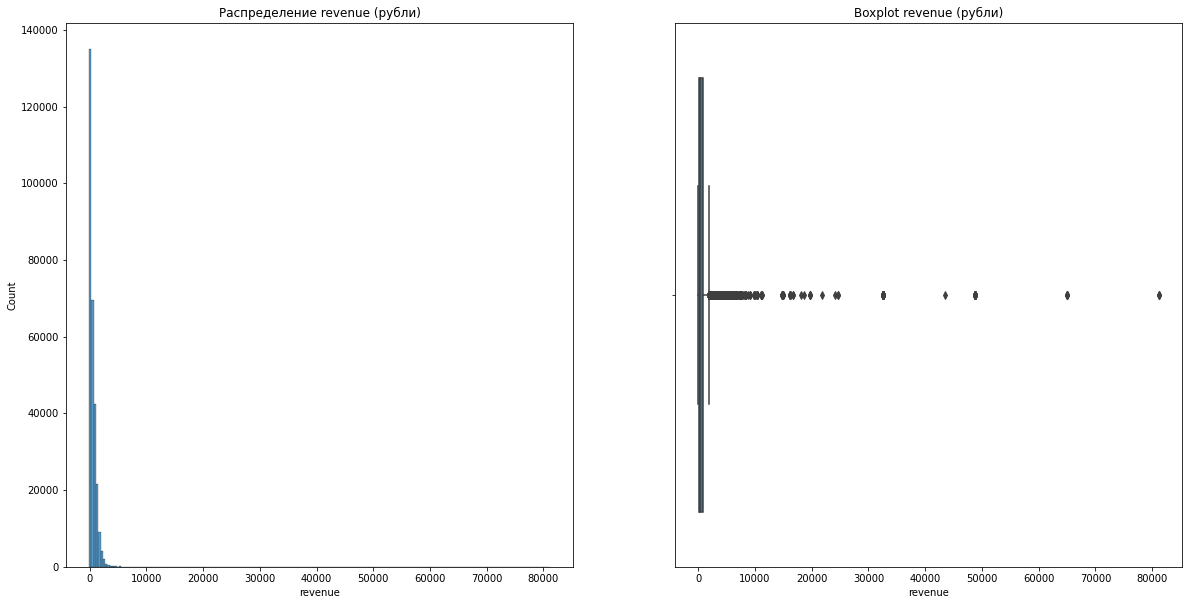

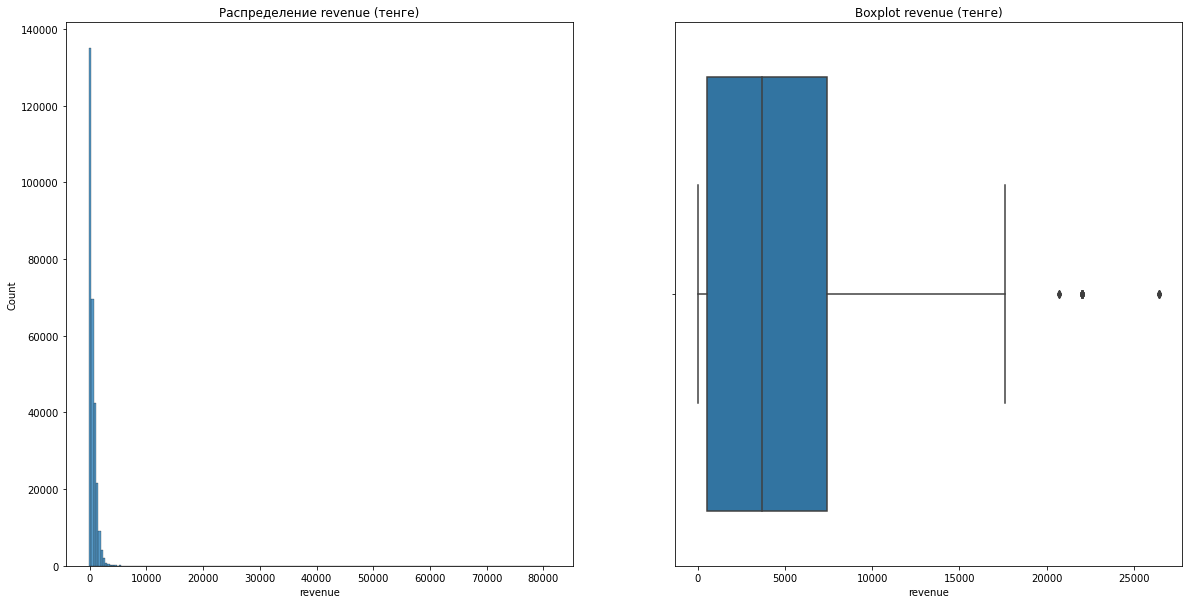

In [26]:
# Проверим распределение revenue и tickets_count
# Для рублей
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
sns.histplot(df_rub['revenue'], bins=200, ax=axes[0])
axes[0].set_title('Распределение revenue (рубли)')
sns.boxplot(x=df_rub['revenue'], ax=axes[1])
axes[1].set_title('Boxplot revenue (рубли)')
plt.show()

# Для тенге — аналогично
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
sns.histplot(df_rub['revenue'], bins=200, ax=axes[0])
axes[0].set_title('Распределение revenue (тенге)')
sns.boxplot(x=df_kzt['revenue'], ax=axes[1])
axes[1].set_title('Boxplot revenue (тенге)')
plt.show()


In [27]:
# Найдем и обработаем некорректные значения поля total: строки с total <= 0
invalid_total_rub = df_rub[df_rub['total'] <= 0]
invalid_total_kzt = df_kzt[df_kzt['total'] <= 0]

print(f"Некорректных total в рублях: {len(invalid_total_rub)}")
print(f'Доля некорректных значений в рублях: {len(invalid_total_rub) / len(df_rub)* 100}%')
print(f"Некорректных total в тенге: {len(invalid_total_kzt)}")
print(f'Доля некорректных значений в тенге: {len(invalid_total_kzt) / len(df_kzt)*100}%')

Некорректных total в рублях: 6093
Доля некорректных значений в рублях: 2.1320596262859546%
Некорректных total в тенге: 6
Доля некорректных значений в тенге: 0.11836654172420596%


In [28]:
#Удалим данные строки, так как их кол-во 2% в рублях и менее 1% процента в тенге
df_rub_clean = df_rub[df_rub['total'] > 0]
df_kzt_clean = df_kzt[df_kzt['total'] > 0]

In [29]:
#Соберём очищенный датафрейм
df_clean = pd.concat([df_rub_clean, df_kzt_clean], axis=0)

In [30]:
#Итоговая проверка
print(f"Было записей: {len(df)}")
print(f"Удалено из-за total <= 0: {len(df) - len(df_clean)}")
print(f"Осталось записей: {len(df_clean)}")

# Проверка, что total <= 0 больше нет
print(f"Осталось total <= 0: {(df_clean['total'] <= 0).sum()}")
df_clean_count = len(df_clean)

Было записей: 290849
Удалено из-за total <= 0: 6099
Осталось записей: 284750
Осталось total <= 0: 0


<a class="anchor" id="2.4-bullet"></a>
**2.4. Проверка явных и неявных дубликатов**

Сделайте акцент на неявных дубликатах по бронированию билета без учёта идентификаторов заказа и, если такие будут, примите обоснованное решение, как их стоит обработать.

In [31]:
# Проверка явных дубликатов
explicit_duplicates = df_clean.duplicated().sum()
print(f"Явных дубликатов (полное совпадение строк): {explicit_duplicates}")

Явных дубликатов (полное совпадение строк): 0


In [32]:
# Выбираем ключевые поля для поиска неявных дубликатов
duplicate_keys = ['user_id', 'event_id', 'created_ts_msk', 'tickets_count', 'total', 'revenue', 'device_type_canonical']

# Находим неявные дубликаты
implicit_duplicates = df_clean[df_clean.duplicated(subset=duplicate_keys, keep=False)]

print(f"Строк, входящих в неявные дубликаты: {len(implicit_duplicates)}")
print(f"Уникальных групп дубликатов: {implicit_duplicates.duplicated(subset=duplicate_keys).sum()}")

Строк, входящих в неявные дубликаты: 75
Уникальных групп дубликатов: 39


In [33]:
# Посмотрим примеры
implicit_duplicates.sort_values(['user_id', 'created_ts_msk']).head(20)

,order_id,user_id,created_dt_msk,created_ts_msk,event_id,cinema_circuit,age_limit,currency_code,device_type_canonical,revenue,...,event_name,event_type_description,event_type_main,organizers,region_name,city_name,city_id,venue_id,venue_name,venue_address
11777,1123983,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
11778,1123867,06eb7897f65b433,2024-08-13,2024-08-13 16:31:07,183706,нет,18,rub,mobile,69.82,...,69796237-909b-42a7-bfb5-c1b8574c4c76,спектакль,театр,№1482,Светополянский округ,Глиноград,54.0,4443.0,"Центр культурного наследия ""Объединение"" и пар...","бул. Карбышева, д. 50"
26894,1930705,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,b33d7a0b-a715-47e3-803e-02482884a73e,концерт,концерты,№5048,Каменевский регион,Глиногорск,213.0,2704.0,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43"
26896,1930763,0dc525d7bacbb0d,2024-07-31,2024-07-31 13:26:11,393430,нет,18,rub,desktop,1556.05,...,b33d7a0b-a715-47e3-803e-02482884a73e,концерт,концерты,№5048,Каменевский регион,Глиногорск,213.0,2704.0,"Летний фестиваль ""Симфония"" Лтд","бул. Боровой, д. 8/1 стр. 43"
53715,1935113,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,...,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерт,концерты,№894,Каменевский регион,Глиногорск,213.0,4363.0,"Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5"
53717,1935171,206ea45ec11d478,2024-10-29,2024-10-29 16:46:54,442183,нет,16,rub,mobile,601.69,...,dcf6f06f-8499-41d7-8bc2-a0e3d7afe313,концерт,концерты,№894,Каменевский регион,Глиногорск,213.0,4363.0,"Студия дизайна ""Лестница"" Лимитед","наб. Школьная, д. 9/8 стр. 7/5"
57217,160922,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,...,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,11036.0,1656.0,"Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39"
57220,160893,2564e3703075008,2024-10-30,2024-10-30 10:04:15,589005,нет,6,rub,mobile,11.23,...,bee8d0cc-282b-492e-9ed8-ec0990f43ffd,выставка,другое,№1810,Яблоневская область,Горяново,11036.0,1656.0,"Модная академия ""Пункт"" Лимитед","бул. Гагарина, д. 39"
68214,3326185,2ecf0a4e24cae13,2024-10-17,2024-10-17 15:25:33,481392,нет,18,rub,mobile,40.33,...,994dca15-357e-4193-9717-fd6e073f1354,спектакль,театр,№5071,Тепляковская область,Горнодолинск,43.0,3873.0,"Клуб истории искусств ""Редкость"" Групп","пр. Маяковского, д. 1"
68215,3326272,2ecf0a4e24cae13,2024-10-17,2024-10-17 15:25:33,481392,нет,18,rub,mobile,40.33,...,994dca15-357e-4193-9717-fd6e073f1354,спектакль,театр,№5071,Тепляковская область,Горнодолинск,43.0,3873.0,"Клуб истории искусств ""Редкость"" Групп","пр. Маяковского, д. 1"


Ожидаемая картина:

Один пользователь купил билеты на одно мероприятие в один момент

Но в базе есть две записи с разными order_id

Все остальные поля (количество билетов, сумма, выручка, тип устройства, сервис и т.д.) — одинаковые.

In [34]:
# Удаляем неявные дубликаты, оставляя первое вхождение
df_clean = df_clean.drop_duplicates(subset=duplicate_keys, keep='first')

In [35]:
# Итоговая проверка
print("=== Результаты очистки от дубликатов ===")
print(f"Было строк: {df_clean_count}")
print(f"Явных дубликатов: {explicit_duplicates}")
print(f"Неявных дубликатов (строк): {len(implicit_duplicates)}")
print(f"Осталось строк: {len(df_clean)}")
print(f"Удалено строк: {df_clean_count - len(df_clean)}")

=== Результаты очистки от дубликатов ===
Было строк: 284750
Явных дубликатов: 0
Неявных дубликатов (строк): 75
Осталось строк: 284711
Удалено строк: 39


<a class="anchor" id="2.5-bullet"></a>
**2.5. Преобразование типов данных**

Обратите внимание на типы данных с датой и временем, а также проверьте возможность снижения размерности количественных данных.

In [36]:
# Выполним преобразование данных с помощьюto_datetime()
df_clean['created_dt_msk'] = pd.to_datetime(df_tickets_orders['created_dt_msk'])
df_clean['created_ts_msk'] = pd.to_datetime(df_tickets_orders['created_ts_msk'])

In [37]:
# Снизим размерность для количественных данных
df_clean['tickets_count'] = df['tickets_count'].astype('int16')
df_clean['age_limit'] = df['age_limit'].astype('int8')

In [38]:
# Для экономии памяти переведем для некоторых категориальных данных тип object в тип category
df_clean['cinema_circuit'] = df_clean['cinema_circuit'].astype('category')
df_clean['service_name'] = df_clean['service_name'].astype('category')
df_clean['event_type_description'] = df_clean['event_type_description'].astype('category')
df_clean['event_type_main'] = df_clean['event_type_main'].astype('category')
df_clean['region_name'] = df_clean['region_name'].astype('category')
df_clean['city_name'] = df_clean['city_name'].astype('category')
df_clean['organizers'] = df_clean['organizers'].astype('category')

In [39]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 284711 entries, 0 to 290727
Data columns (total 24 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                284711 non-null  int64         
 1   user_id                 284711 non-null  object        
 2   created_dt_msk          284711 non-null  datetime64[ns]
 3   created_ts_msk          284711 non-null  datetime64[ns]
 4   event_id                284711 non-null  int64         
 5   cinema_circuit          284711 non-null  category      
 6   age_limit               284711 non-null  int8          
 7   currency_code           284711 non-null  object        
 8   device_type_canonical   284711 non-null  object        
 9   revenue                 284711 non-null  float64       
 10  service_name            284711 non-null  category      
 11  tickets_count           284711 non-null  int16         
 12  total                   284711

<a class="anchor" id="2.6-bullet"></a>
**2.6. Создание новых столбцов**

In [40]:
# Переименуем названия столбцов датасета с курсом валют
df_tickets_tenge.rename(columns={
    'data': 'date',
    'nominal': 'face_value',
    'curs': 'exchange_rate',
    'cdx': 'currency_code'
}, inplace=True)

In [41]:
df_tickets_tenge['date'] = pd.to_datetime(df_tickets_tenge['date'])

In [42]:
df_tickets_tenge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 357 entries, 0 to 356
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           357 non-null    datetime64[ns]
 1   face_value     357 non-null    int64         
 2   exchange_rate  357 non-null    float64       
 3   currency_code  357 non-null    object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(1)
memory usage: 11.3+ KB


In [43]:
# Создаём столбец revenue_rub (выручка в рублях)
# Объединяем с курсами по дате
df_clean = df_clean.merge(df_tickets_tenge[['date', 'exchange_rate']], 
                           left_on=df_clean['created_dt_msk'], 
                           right_on='date', 
                           how='left')

In [44]:
# Рассчитываем revenue_rub с учётом валюты
# Если валюта rub - оставляем как есть, еcли kzt - переводим по курсу
# revenue_rub = (revenue / 100) * exchange_rate
df_clean['revenue_rub'] = df_clean.apply(
    lambda row: row['revenue'] if 
row['currency_code'] == 'rub'
else (row['revenue'] / 100) * row['exchange_rate'],
    axis=1
)

In [45]:
#Удаляем лишние столбцы после объединения и расчётов
df_clean.drop(columns=['date', 'exchange_rate'], inplace=True)

In [46]:
df_clean[['created_dt_msk', 'revenue', 'currency_code', 'revenue_rub']]

,created_dt_msk,revenue,currency_code,revenue_rub
0,2024-08-20,1521.94,rub,1521.940000
1,2024-07-23,289.45,rub,289.450000
2,2024-10-06,1258.57,rub,1258.570000
3,2024-07-13,8.49,rub,8.490000
4,2024-10-04,1390.41,rub,1390.410000
...,...,...,...,...
284706,2024-07-11,4735.52,kzt,865.359454
284707,2024-09-05,4735.52,kzt,872.363288
284708,2024-09-06,1849.41,kzt,343.072953
284709,2024-06-21,3698.83,kzt,687.209325


In [47]:
# Создаём столбец one_ticket_revenue_rub (выручка с одного билета)
df_clean['one_ticket_revenue_rub'] = df_clean['revenue_rub'] / df_clean['tickets_count']

In [48]:
# Выделим месяц оформления заказа в отдельный столбец
df_clean['month'] = df_clean['created_dt_msk'].dt.month

In [49]:
# Создаём столбец season (сезон)
def get_season(month):
    if month in [12, 1, 2]:
        return 'зима'
    elif month in [3, 4, 5]:
        return 'весна'
    elif month in [6, 7, 8]:
        return 'лето'
    elif month in [9, 10, 11]:
        return 'осень'
    
df_clean['season'] = df_clean['month'].apply(get_season)

In [50]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 284711 entries, 0 to 284710
Data columns (total 28 columns):
 #   Column                  Non-Null Count   Dtype         
---  ------                  --------------   -----         
 0   order_id                284711 non-null  int64         
 1   user_id                 284711 non-null  object        
 2   created_dt_msk          284711 non-null  datetime64[ns]
 3   created_ts_msk          284711 non-null  datetime64[ns]
 4   event_id                284711 non-null  int64         
 5   cinema_circuit          284711 non-null  category      
 6   age_limit               284711 non-null  int8          
 7   currency_code           284711 non-null  object        
 8   device_type_canonical   284711 non-null  object        
 9   revenue                 284711 non-null  float64       
 10  service_name            284711 non-null  category      
 11  tickets_count           284711 non-null  int16         
 12  total                   284711

In [51]:
# Проверка результата
df_clean[['created_dt_msk', 'revenue', 'revenue_rub', 
                'tickets_count', 'one_ticket_revenue_rub', 
                'month', 'season']].head(10)

,created_dt_msk,revenue,revenue_rub,tickets_count,one_ticket_revenue_rub,month,season
0,2024-08-20,1521.94,1521.94,4,380.485000,8,лето
1,2024-07-23,289.45,289.45,2,144.725000,7,лето
2,2024-10-06,1258.57,1258.57,4,314.642500,10,осень
3,2024-07-13,8.49,8.49,2,4.245000,7,лето
4,2024-10-04,1390.41,1390.41,3,463.470000,10,осень
5,2024-10-23,902.74,902.74,3,300.913333,10,осень
6,2024-08-15,917.83,917.83,4,229.457500,8,лето
7,2024-09-29,47.78,47.78,1,47.780000,9,осень
8,2024-10-15,74.84,74.84,2,37.420000,10,осень
9,2024-06-20,1421.91,1421.91,4,355.477500,6,лето


**Проверка количества данных после предобработки**
Поэтапный подсчет:

Исходные данные (после объединения, `df_tickets_orders` + `df_tickets_events`): 298 849.

После удаления выбросов (`total` <= 0): 284 750. Удалено 6 099 записей(2.04%).

После удаления неявных дубликатов:	284 711. Удалено 39 записей.

Итоговый датасет `df_clean`:	284 711	

✅ Готов к анализу


**Промежуточный вывод**
1. **Основные действия предобработки**
- Проверка пропусков: в столбце `days_since_prev` 21 940 пропусков (это нормально, т.к. для первых заказов пользователей нет предыдущей даты). В остальных столбцах пропусков нет.

2. **Объединение датафреймов:** выполнен `LEFT JOIN` заказов с мероприятиями по `event_id`. Обнаружено 238 заказов без описания мероприятия (фильмы и другие события, исключённые по условию). Эти записи не удалялись, чтобы не исказить анализ выручки.

3. **Исследование значений:** 

- Анализ котегориальных полей: выполнена нормализация текста (приведение к нижнему регистру, удаление пробелов). Обнаружено 2 валюты (rub, kzt), 2 типа устройств (mobile, desktop), 36 сервисов-партнёров, 6 организаторов, 81 регион, 352 города.

- Анализ количественных полей:

    * `tickets_count`: от 1 до 57, среднее 2.75 билета на заказ

    * `age_limit`: от 0 до 18 лет

Обнаружены отрицательные и нулевые значения в `revenue` и `total` (обосновано баллами Плюса, промоакциями, техническими сбоями)

Обработка выбросов:

Высокие значения revenue признаны реальными данными (премиальные билеты, сервис «Облачко») — удаление по 99-му процентилю не применялось

Удалены только строки с `total` <= 0 (6,099 записей, ~2%)

4. **Удаление дубликатов:**

Явных дубликатов: 0

Неявных дубликатов (одинаковый пользователь, событие, время, кол-во билетов, сумма): 75 строк, удалено 39

5. **Преобразование типов:**

Даты переведены в `datetime64`

`tickets_count` → `int16`, `age_limit` → `int8` (экономия памяти)

Категориальные поля → `categor` (7 столбцов)

6. **Создание новых столбцов:**

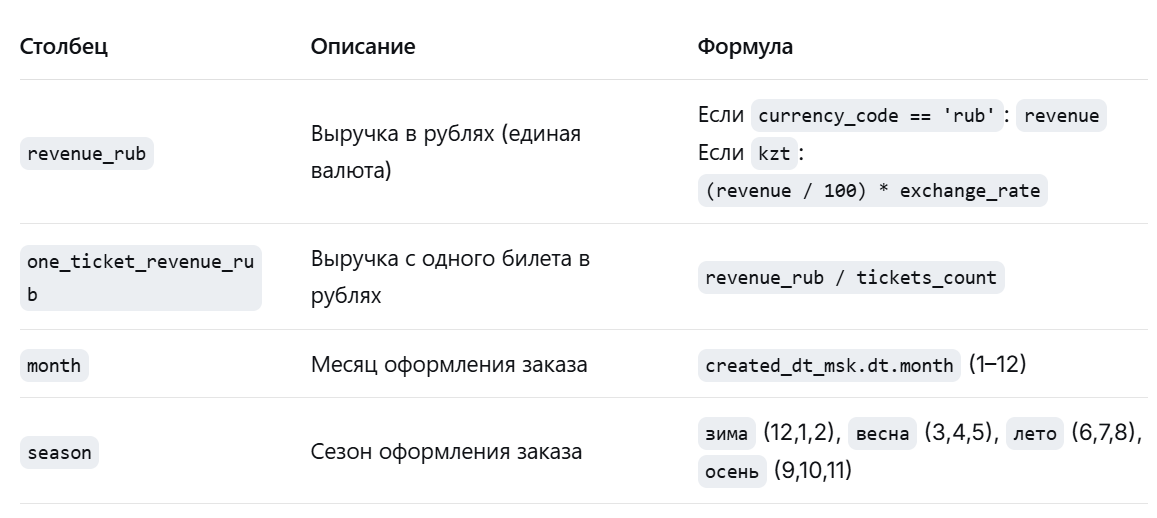

**Итог**

После полной предобработки и создания новых признаков датасет `df_clean` содержит 284 711 записей и 28 столбцов, готов к дальнейшему исследованию.
Итоговый размер памяти: `46.9 MB`

<a class="anchor" id="3-bullet"></a>
## Шаг 3. Исследовательский анализ данных

<a class="anchor" id="3.1-bullet"></a>
**3.1. Анализ распределения заказов по сегментам и их сезонные изменения**

In [52]:
# Настройка визуализации
sns.set_style('whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

- **Количество заказов по месяцам**

In [53]:
# Убеждаемся, что в данных нет заказов в ноябре месяце. Значит, анализируем с июня по октябрь.
df_clean['month'].unique()

array([ 8,  7, 10,  9,  6])

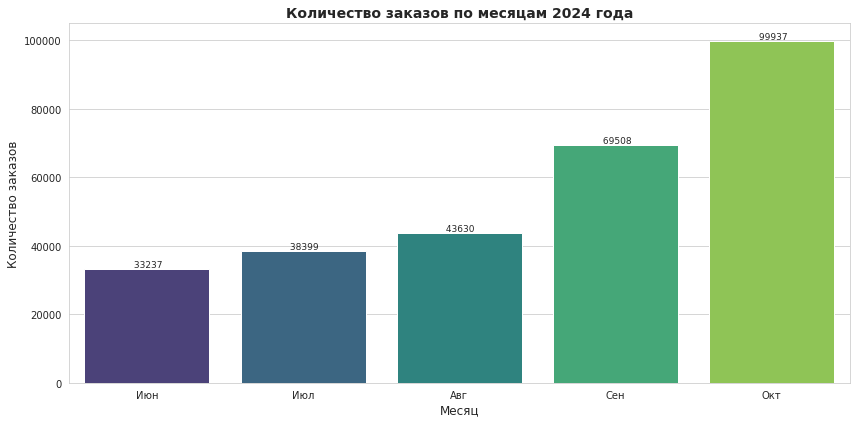

=== Количество заказов по месяцам ===
 month  orders_count month_name
     6         33237        Июн
     7         38399        Июл
     8         43630        Авг
     9         69508        Сен
    10         99937        Окт

Рост с июня (6) по октябрь (10):
  Июнь:  33237 заказов
  Октябрь:  99937 заказов
  Рост: 200.7%


In [54]:
# 1. Количество заказов по месяцам
monthly_orders = df_clean.groupby('month').size().reset_index(name='orders_count')

# Добавим название месяца для наглядности
month_names = {1: 'Янв', 2: 'Фев', 3: 'Мар', 4: 'Апр', 5: 'Май', 6: 'Июн',
               7: 'Июл', 8: 'Авг', 9: 'Сен', 10: 'Окт'}
monthly_orders['month_name'] = monthly_orders['month'].map(month_names)

# Визуализация
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=monthly_orders, x='month_name', y='orders_count', ax=ax, palette='viridis')
ax.set_title('Количество заказов по месяцам 2024 года', fontsize=14, fontweight='bold')
ax.set_xlabel('Месяц', fontsize=12)
ax.set_ylabel('Количество заказов', fontsize=12)

# Добавляем значения на столбцы
for i, v in enumerate(monthly_orders['orders_count']):
    ax.text(i, v + 500, f'{v: }', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

print("=== Количество заказов по месяцам ===")
print(monthly_orders.to_string(index=False))
print(f"\nРост с июня (6) по октябрь (10):")
june_orders = monthly_orders[monthly_orders['month']==6]['orders_count'].values[0]
oct_orders = monthly_orders[monthly_orders['month']==10]['orders_count'].values[0]
print(f"  Июнь: {june_orders: } заказов")
print(f"  Октябрь: {oct_orders: } заказов")
print(f"  Рост: {(oct_orders/june_orders - 1)*100:.1f}%")

- **Сравнение летнего и осеннего периодов (по долям)**

=== Доли заказов по типу мероприятия (лето vs осень) ===
season           лето  осень
event_type_main             
выставки          2.1    1.4
другое           24.9   19.3
концерты         44.0   37.6
спорт             2.4   11.1
стендап           5.6    4.1
театр            20.8   25.4
ёлки              0.2    1.0

=== Доли заказов по типу устройства ===
season                 лето  осень
device_type_canonical             
desktop                19.2   20.4
mobile                 80.8   79.6

=== Доли заказов по возрастному рейтингу ===
season     лето  осень
age_limit             
0          18.1   23.2
6          18.4   17.8
12         21.3   22.2
16         28.3   26.3
18         13.9   10.5


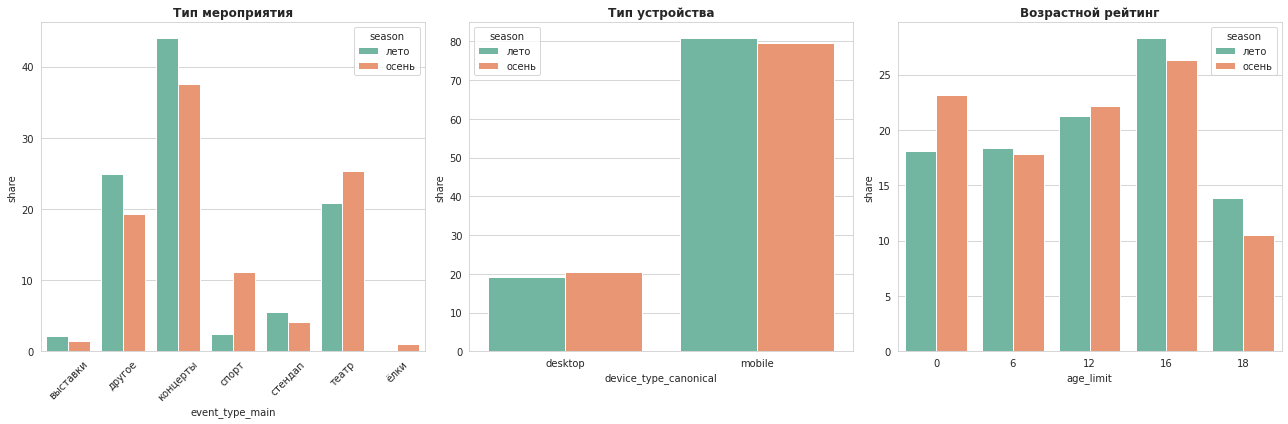

In [55]:
# 2. Сравнение летнего и осеннего периодов (упрощённый)

# Отбираем только лето и осень
df_seasonal = df_clean[df_clean['season'].isin(['лето', 'осень'])].copy()

# Функция для расчёта долей
def compute_shares(df, group_col):
    shares = pd.crosstab(df[group_col], df['season'], normalize='columns') * 100
    return shares.round(1)

# 2.1. По типу мероприятия
event_shares = compute_shares(df_seasonal, 'event_type_main')
print("=== Доли заказов по типу мероприятия (лето vs осень) ===")
print(event_shares)

# 2.2. По типу устройства
device_shares = compute_shares(df_seasonal, 'device_type_canonical')
print("\n=== Доли заказов по типу устройства ===")
print(device_shares)

# 2.3. По возрастному рейтингу
age_shares = compute_shares(df_seasonal, 'age_limit')
print("\n=== Доли заказов по возрастному рейтингу ===")
print(age_shares)

# Визуализация
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# График 1: Тип мероприятия
event_shares.reset_index().melt(id_vars='event_type_main', var_name='season', value_name='share')
sns.barplot(data=event_shares.reset_index().melt(id_vars='event_type_main', var_name='season', value_name='share'), 
            x='event_type_main', y='share', hue='season', ax=axes[0])
axes[0].set_title('Тип мероприятия', fontweight='bold')
axes[0].tick_params(axis='x', rotation=45)

# График 2: Тип устройства
sns.barplot(data=device_shares.reset_index().melt(id_vars='device_type_canonical', var_name='season', value_name='share'), 
            x='device_type_canonical', y='share', hue='season', ax=axes[1])
axes[1].set_title('Тип устройства', fontweight='bold')

# График 3: Возрастной рейтинг
age_filtered = age_shares.reset_index().melt(id_vars='age_limit', var_name='season', value_name='share')
age_filtered = age_filtered[age_filtered['age_limit'].isin([0, 6, 12, 16, 18])]
sns.barplot(data=age_filtered, x='age_limit', y='share', hue='season', ax=axes[2])
axes[2].set_title('Возрастной рейтинг', fontweight='bold')

plt.tight_layout()
plt.show()

- **Изменение выручки с одного билета по типам мероприятий**

=== Изменение средней выручки с одного билета (лето → осень) ===
event_type_main  summer_mean  autumn_mean  change_%
        стендап       227.07       249.96      10.1
       выставки        86.74        92.37       6.5
          спорт        58.88        52.43     -11.0
       концерты       323.99       286.82     -11.5
         другое        92.10        78.41     -14.9
           ёлки       276.39       234.50     -15.2
          театр       224.79       183.11     -18.5


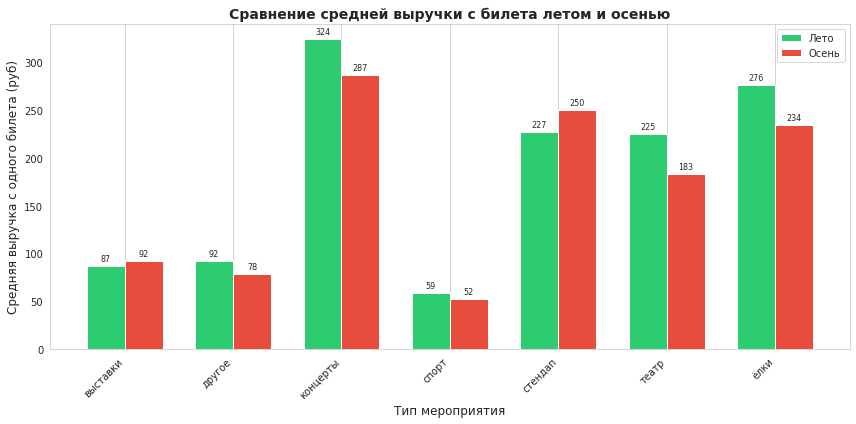

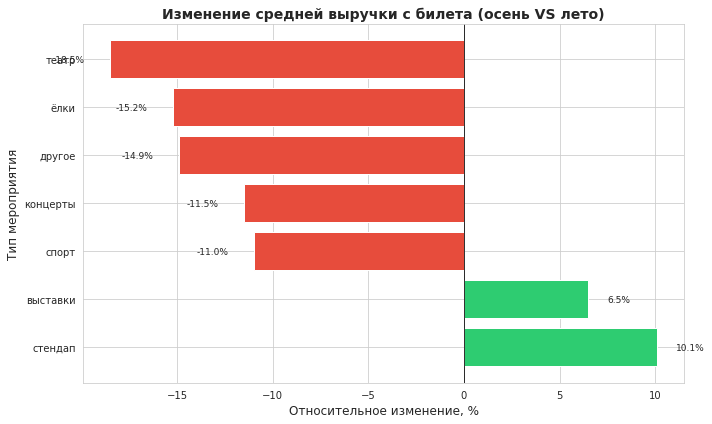

In [56]:
# 3. Анализ выручки с одного билета

# Рассчитываем среднюю выручку на билет для каждого типа мероприятия по сезонам
seasonal_revenue = df_seasonal.groupby(['event_type_main', 'season'])['one_ticket_revenue_rub'].agg(['mean', 'median', 'count']).round(2)
seasonal_revenue = seasonal_revenue.reset_index()

# Подготовка для расчёта относительного изменения
summer_revenue = seasonal_revenue[seasonal_revenue['season'] == 'лето'][['event_type_main', 'mean']]
autumn_revenue = seasonal_revenue[seasonal_revenue['season'] == 'осень'][['event_type_main', 'mean']]

# Переименовываем для объединения
summer_revenue.columns = ['event_type_main', 'summer_mean']
autumn_revenue.columns = ['event_type_main', 'autumn_mean']

# Объединяем и рассчитываем изменение
revenue_change = summer_revenue.merge(autumn_revenue, on='event_type_main', how='inner')
revenue_change['change_%'] = ((revenue_change['autumn_mean'] - revenue_change['summer_mean']) / revenue_change['summer_mean'] * 100).round(1)
revenue_change = revenue_change.sort_values('change_%', ascending=False)

print("=== Изменение средней выручки с одного билета (лето → осень) ===")
print(revenue_change.to_string(index=False))

# Визуализация
fig, ax = plt.subplots(figsize=(12, 6))

# Создаём grouped bar chart
plot_data = seasonal_revenue.pivot(index='event_type_main', columns='season', values='mean')
plot_data = plot_data[['лето', 'осень']].dropna()

x = np.arange(len(plot_data.index))
width = 0.35

bars1 = ax.bar(x - width/2, plot_data['лето'], width, label='Лето', color='#2ecc71')
bars2 = ax.bar(x + width/2, plot_data['осень'], width, label='Осень', color='#e74c3c')

ax.set_xlabel('Тип мероприятия', fontsize=12)
ax.set_ylabel('Средняя выручка с одного билета (руб)', fontsize=12)
ax.set_title('Сравнение средней выручки с билета летом и осенью', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(plot_data.index, rotation=45, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Добавляем значения на столбцы
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(f'{height:.0f}',
                       xy=(bar.get_x() + bar.get_width()/2, height),
                       xytext=(0, 3),
                       textcoords="offset points",
                       ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

# Дополнительная визуализация: относительное изменение
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#2ecc71' if x > 0 else '#e74c3c' for x in revenue_change['change_%']]
bars = ax.barh(revenue_change['event_type_main'], revenue_change['change_%'], color=colors)
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax.set_xlabel('Относительное изменение, %', fontsize=12)
ax.set_ylabel('Тип мероприятия', fontsize=12)
ax.set_title('Изменение средней выручки с билета (осень VS лето)', fontsize=14, fontweight='bold')

# Добавляем значения
for bar, change in zip(bars, revenue_change['change_%']):
    ax.text(bar.get_width() + (1 if change > 0 else -3), 
            bar.get_y() + bar.get_height()/2, 
            f'{change}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [57]:
# 4. Детальный анализ изменений в структуре

print("\n" + "="*60)
print("АНАЛИЗ ИЗМЕНЕНИЙ СТРУКТУРЫ ЗАКАЗОВ")
print("="*60)

# Подробный анализ по каждому разрезу
print("\n 1. ИЗМЕНЕНИЕ ДОЛИ ЗАКАЗОВ ПО ТИПУ МЕРОПРИЯТИЯ:")
for event in event_shares.index:
    summer_share = event_shares.loc[event, 'лето']
    autumn_share = event_shares.loc[event, 'осень']
    change = autumn_share - summer_share
    if change > 0:
        arrow = "↑" 
    elif change < 0:
        arrow = "↓" 
    else:
        arrow = "→"
    print(f"   {event:12} | лето: {summer_share:5.1f}% | осень: {autumn_share:5.1f}% | изменение: {arrow} {abs(change):.1f} п.п.")

print("\n 2. ИЗМЕНЕНИЕ ДОЛИ ЗАКАЗОВ ПО ТИПУ УСТРОЙСТВА:")
for device in device_shares.index:
    summer_share = device_shares.loc[device, 'лето']
    autumn_share = device_shares.loc[device, 'осень']
    change = autumn_share - summer_share
    if change > 0:
        arrow = "↑" 
    else:
        arrow = "↓"
    print(f"   {device:10} | лето: {summer_share:5.1f}% | осень: {autumn_share:5.1f}% | изменение: {arrow} {abs(change):.1f} п.п.")

print("\n 3. ИЗМЕНЕНИЕ СРЕДНЕЙ ВЫРУЧКИ С БИЛЕТА:")
for _, row in revenue_change.iterrows():
    if row['change_%'] > 0:
        change_sign = "▲" 
    elif row['change_%'] < 0:
        change_sign = "▼" 
    else:
        change_sign = "●"
    print(f"   {row['event_type_main']:12} | лето: {row['summer_mean']:8.0f} руб | осень: {row['autumn_mean']:8.0f} руб | {change_sign} {row['change_%']:+.1f}%")


АНАЛИЗ ИЗМЕНЕНИЙ СТРУКТУРЫ ЗАКАЗОВ

 1. ИЗМЕНЕНИЕ ДОЛИ ЗАКАЗОВ ПО ТИПУ МЕРОПРИЯТИЯ:
   выставки     | лето:   2.1% | осень:   1.4% | изменение: ↓ 0.7 п.п.
   другое       | лето:  24.9% | осень:  19.3% | изменение: ↓ 5.6 п.п.
   концерты     | лето:  44.0% | осень:  37.6% | изменение: ↓ 6.4 п.п.
   спорт        | лето:   2.4% | осень:  11.1% | изменение: ↑ 8.7 п.п.
   стендап      | лето:   5.6% | осень:   4.1% | изменение: ↓ 1.5 п.п.
   театр        | лето:  20.8% | осень:  25.4% | изменение: ↑ 4.6 п.п.
   ёлки         | лето:   0.2% | осень:   1.0% | изменение: ↑ 0.8 п.п.

 2. ИЗМЕНЕНИЕ ДОЛИ ЗАКАЗОВ ПО ТИПУ УСТРОЙСТВА:
   desktop    | лето:  19.2% | осень:  20.4% | изменение: ↑ 1.2 п.п.
   mobile     | лето:  80.8% | осень:  79.6% | изменение: ↓ 1.2 п.п.

 3. ИЗМЕНЕНИЕ СРЕДНЕЙ ВЫРУЧКИ С БИЛЕТА:
   стендап      | лето:      227 руб | осень:      250 руб | ▲ +10.1%
   выставки     | лето:       87 руб | осень:       92 руб | ▲ +6.5%
   спорт        | лето:       59 руб | осень:       

**ВЫВОД**

1. ДИНАМИКА ЗАКАЗОВ:

- Наблюдается чёткий рост количества заказов с июня по октябрь 2024 года

- Пик заказов приходится на октябрь (99 937 заказов)

- Рост с июня по октябрь составляет 200.7% (заказы выросли в 3 раза)

2. ИЗМЕНЕНИЕ СТРУКТУРЫ ЗАКАЗОВ ПО ТИПАМ МЕРОПРИЯТИЙ:

Тип мероприятия	  Изменение доли
- спорт	           ↑ +8.7 п.п.
- театр	           ↑ +4.6 п.п.
- ёлки	           ↑ +0.8 п.п.
- концерты	       ↓ -6.4 п.п.
- другое	       ↓ -5.6 п.п.
- стендап	       ↓ -1.5 п.п.
- выставки	       ↓ -0.7 п.п.

    Дополнительное наблюдение: Осенью заметно выросла доля спорта (+8.7 п.п.) и театра (+4.6 п.п.), что может быть связано с началом сезона в этих сферах. Также появляются ёлки (сезонный фактор, +0.8 п.п.). Наблюдаетс увеличение числа семейных мероприятий.

3. ИЗМЕНЕНИЕ ПОВЕДЕНИЯ ПО ТИПУ УСТРОЙСТВ:

- Мобильные устройства: доля снизилась на 1.2 п.п. (80.8% → 79.6%)

- Десктоп: доля выросла на 1.2 п.п. (19.2% → 20.4%)

Доля мобильных устройств незначительно снижается. Возможно, пользователи переходят на десктоп для планирования осенних мероприятий или на десктопе удобнее покупать билеты на несколько событий сразу.

4. ДИНАМИКА СРЕДНЕЙ ВЫРУЧКИ С БИЛЕТА:

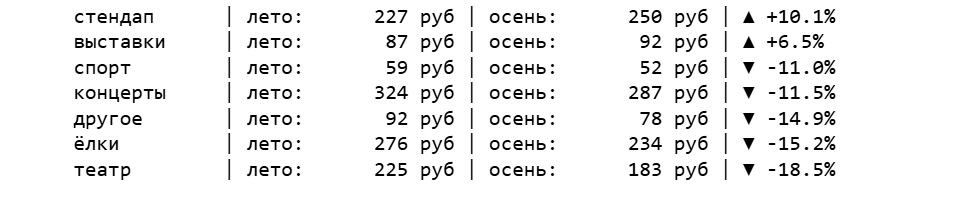


С наступлением осени наблюдается количественный рост заказов (в 3 раза с июня по октябрь) и качественное изменение структуры спроса:

- Растёт доля спортивных мероприятий и театров — вероятно, начало сезона

- Снижается средний чек по большинству категорий (театр -18.5%, ёлки -15.2%, концерты -11.5%). Исключение — стендап и выставки — здесь средний чек вырос (+10% и +6.5% соответственно)

- Доля мобильных устройств незначительно снизилась (на 1.2 п.п.) — возможно, десктоп удобнее для планирования осенней активности

Рекомендация: Обратить внимание на падение среднего чека в театрах и на концертах — возможно, требуется пересмотр ценовой политики или введение дополнительных услуг для повышения ценности билета.

<a class="anchor" id="3.2-bullet"></a>
**3.2. Осенняя активность пользователей**

In [58]:
# 1. Отбор осенних данных (сентябрь и октябрь)
autumn_data = df_clean[df_clean['month'].isin([9, 10])].copy()

print("=== Осенние данные ===")
print(f"Период: сентябрь - октябрь 2024")
print(f"Количество записей: {len(autumn_data):}")
print(f"Уникальных пользователей: {autumn_data['user_id'].nunique():}")
print(f"Диапазон дат: {autumn_data['created_dt_msk'].min().date()} - {autumn_data['created_dt_msk'].max().date()}")

=== Осенние данные ===
Период: сентябрь - октябрь 2024
Количество записей: 169445
Уникальных пользователей: 15800
Диапазон дат: 2024-09-01 - 2024-10-31


- **Анализ динамики изменений по дням**

In [59]:
# 2. Создание дневной сводной таблицы

# Извлекаем дату (без времени)
autumn_data['date_only'] = autumn_data['created_dt_msk'].dt.date

# Сводная таблица по дням
daily_stats = autumn_data.groupby('date_only').agg(
    orders_count=('order_id', 'count'),
    active_users=('user_id', 'nunique'),
    avg_revenue_per_ticket=('one_ticket_revenue_rub', 'mean'),
    total_revenue=('revenue_rub', 'sum')
).reset_index()

# Рассчитываем среднее число заказов на одного пользователя
daily_stats['orders_per_user'] = daily_stats['orders_count'] / daily_stats['active_users']

# Добавляем день недели для анализа
weekday_names = {0: 'ПН', 1: 'ВТ', 2: 'СР', 3: 'ЧТ', 4: 'ПТ', 5: 'СБ', 6: 'ВС'}
daily_stats['weekday'] = pd.to_datetime(daily_stats['date_only']).dt.dayofweek.map(weekday_names)
daily_stats['day_of_week'] = pd.to_datetime(daily_stats['date_only']).dt.dayofweek
daily_stats['weekday_name'] = pd.to_datetime(daily_stats['date_only']).dt.day_name()
print("\n=== Первые 5 дней осеннего периода ===")
print(daily_stats.head().round(2))



=== Первые 5 дней осеннего периода ===
    date_only  orders_count  active_users  avg_revenue_per_ticket  \
0  2024-09-01          1335           560                  210.14   
1  2024-09-02          1381           577                  196.95   
2  2024-09-03          5101           781                   82.47   
3  2024-09-04          1769           686                  185.67   
4  2024-09-05          1956           744                  194.91   

   total_revenue  orders_per_user weekday  day_of_week weekday_name  
0      790344.90             2.38      ВС            6       Sunday  
1      744061.63             2.39      ПН            0       Monday  
2     1196803.31             6.53      ВТ            1      Tuesday  
3      910949.33             2.58      СР            2    Wednesday  
4     1047460.81             2.63      ЧТ            3     Thursday  


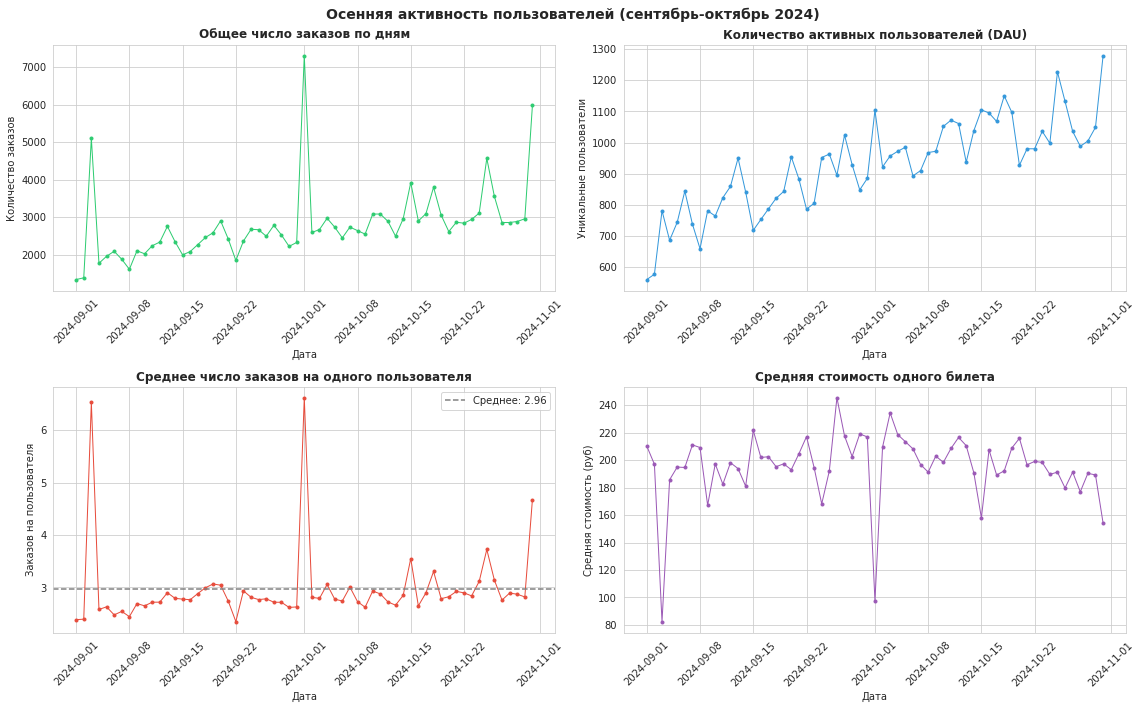

In [60]:
# 3. Визуализация дневной динамики
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Осенняя активность пользователей (сентябрь-октябрь 2024)', fontsize=14, fontweight='bold')

# График 1: Общее число заказов по дням
axes[0, 0].plot(daily_stats['date_only'], daily_stats['orders_count'], marker='o', linestyle='-', 
                linewidth=1, markersize=3, color='#2ecc71')
axes[0, 0].set_title('Общее число заказов по дням', fontweight='bold')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Количество заказов')
axes[0, 0].tick_params(axis='x', rotation=45)

# График 2: Количество активных пользователей (DAU)
axes[0, 1].plot(daily_stats['date_only'], daily_stats['active_users'], marker='o', linestyle='-', 
                linewidth=1, markersize=3, color='#3498db')
axes[0, 1].set_title('Количество активных пользователей (DAU)', fontweight='bold')
axes[0, 1].set_xlabel('Дата')
axes[0, 1].set_ylabel('Уникальные пользователи')
axes[0, 1].tick_params(axis='x', rotation=45)

# График 3: Среднее число заказов на одного пользователя
axes[1, 0].plot(daily_stats['date_only'], daily_stats['orders_per_user'], marker='o', linestyle='-', 
                linewidth=1, markersize=3, color='#e74c3c')
axes[1, 0].set_title('Среднее число заказов на одного пользователя', fontweight='bold')
axes[1, 0].set_xlabel('Дата')
axes[1, 0].set_ylabel('Заказов на пользователя')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].axhline(y=daily_stats['orders_per_user'].mean(), color='gray', linestyle='--', 
                   label=f"Среднее: {daily_stats['orders_per_user'].mean():.2f}")
axes[1, 0].legend()

# График 4: Средняя стоимость одного билета
axes[1, 1].plot(daily_stats['date_only'], daily_stats['avg_revenue_per_ticket'], marker='o', linestyle='-', 
                linewidth=1, markersize=3, color='#9b59b6')
axes[1, 1].set_title('Средняя стоимость одного билета', fontweight='bold')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Средняя стоимость (руб)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

- **Недельная цикличность**


=== Недельная цикличность (средние значения по дням недели) ===
 day_of_week weekday  orders_count  active_users  orders_per_user  avg_revenue_per_ticket
           0      ПН       2407.00        857.44             2.79                  193.15
           1      ВТ       3518.11        938.44             3.73                  165.15
           2      СР       2562.22        929.67             2.75                  195.83
           3      ЧТ       3033.44        966.11             3.07                  200.12
           4      ПТ       3118.50       1024.12             3.01                  201.16
           5      СБ       2674.38        958.25             2.78                  202.18
           6      ВС       2157.22        818.22             2.62                  211.40


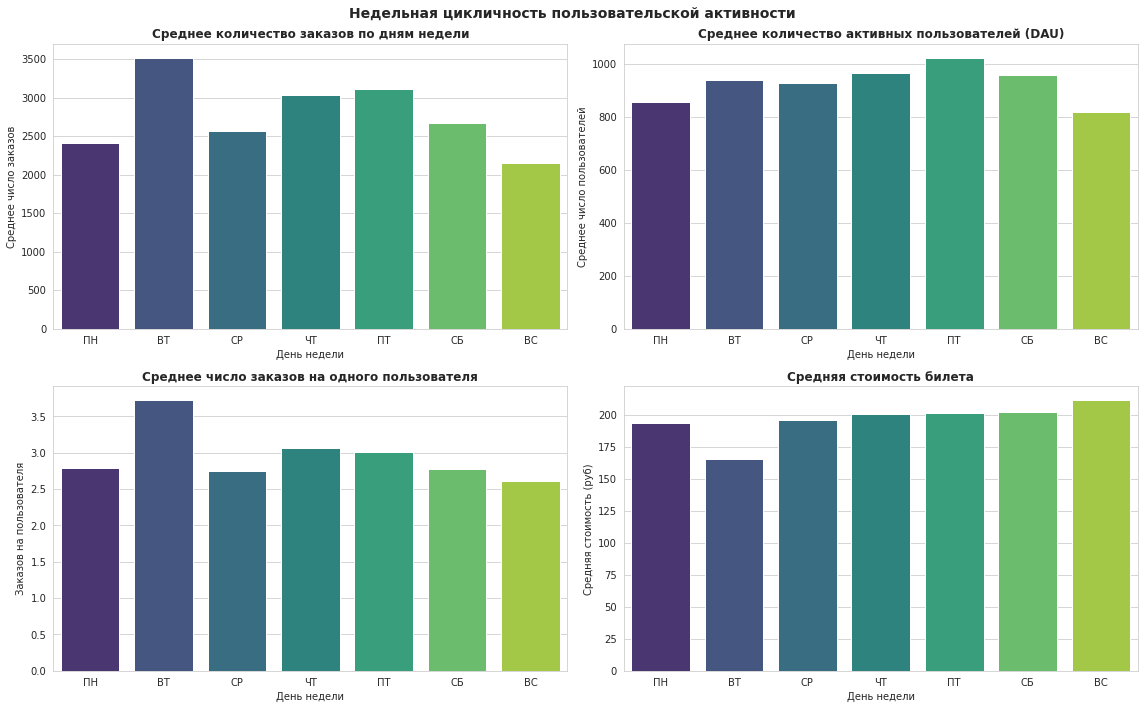

In [61]:
# 5. Анализ недельной цикличности
# ============================================

# Группировка по дням недели
weekly_pattern = daily_stats.groupby(['day_of_week', 'weekday']).agg(
    orders_count=('orders_count', 'mean'),
    active_users=('active_users', 'mean'),
    orders_per_user=('orders_per_user', 'mean'),
    avg_revenue_per_ticket=('avg_revenue_per_ticket', 'mean')
).reset_index()

# Сортируем по дням недели (ПН=0, ВС=6)
weekly_pattern = weekly_pattern.sort_values('day_of_week')

print("\n=== Недельная цикличность (средние значения по дням недели) ===")
print(weekly_pattern.round(2).to_string(index=False))

# Визуализация недельной цикличности
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Недельная цикличность пользовательской активности', fontsize=14, fontweight='bold')

# Заказы по дням недели
sns.barplot(data=weekly_pattern, x='weekday', y='orders_count', palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Среднее количество заказов по дням недели', fontweight='bold')
axes[0, 0].set_xlabel('День недели')
axes[0, 0].set_ylabel('Среднее число заказов')

# Активные пользователи по дням недели
sns.barplot(data=weekly_pattern, x='weekday', y='active_users', palette='viridis', ax=axes[0, 1])
axes[0, 1].set_title('Среднее количество активных пользователей (DAU)', fontweight='bold')
axes[0, 1].set_xlabel('День недели')
axes[0, 1].set_ylabel('Среднее число пользователей')

# Заказов на пользователя по дням недели
sns.barplot(data=weekly_pattern, x='weekday', y='orders_per_user', palette='viridis', ax=axes[1, 0])
axes[1, 0].set_title('Среднее число заказов на одного пользователя', fontweight='bold')
axes[1, 0].set_xlabel('День недели')
axes[1, 0].set_ylabel('Заказов на пользователя')

# Средняя стоимость билета по дням недели
sns.barplot(data=weekly_pattern, x='weekday', y='avg_revenue_per_ticket', palette='viridis', ax=axes[1, 1])
axes[1, 1].set_title('Средняя стоимость билета', fontweight='bold')
axes[1, 1].set_xlabel('День недели')
axes[1, 1].set_ylabel('Средняя стоимость (руб)')

plt.tight_layout()
plt.show()


=== Сравнение будней и выходных ===
             orders_count  active_users  orders_per_user  \
period_type                                                
weekday           2923.52        941.32             3.07   
weekend           2400.59        884.12             2.69   

             avg_revenue_per_ticket  
period_type                          
weekday                      190.85  
weekend                      207.06  


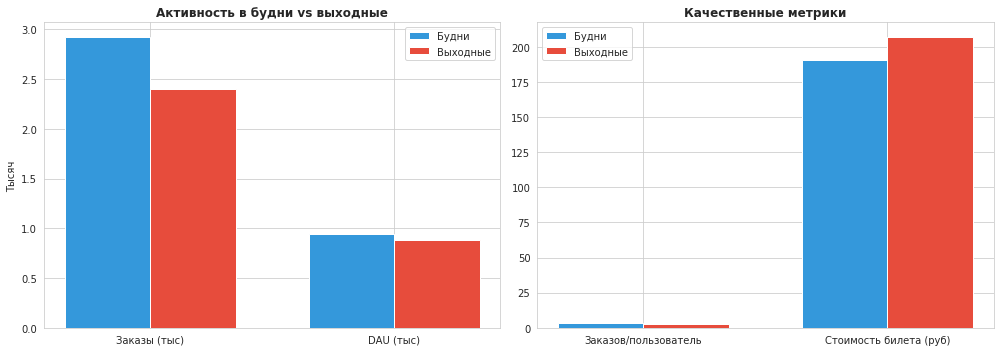

In [62]:
# 6. Сравнение будней и выходных

# Определяем будни (ПН-ПТ = 0-4) и выходные (СБ-ВС = 5-6)
daily_stats['period_type'] = daily_stats['day_of_week'].apply(
    lambda x: 'weekend' if x >= 5 else 'weekday'
)

weekday_vs_weekend = daily_stats.groupby('period_type').agg(
    orders_count=('orders_count', 'mean'),
    active_users=('active_users', 'mean'),
    orders_per_user=('orders_per_user', 'mean'),
    avg_revenue_per_ticket=('avg_revenue_per_ticket', 'mean')
).round(2)

print("\n=== Сравнение будней и выходных ===")
print(weekday_vs_weekend)

# Визуализация сравнения
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Заказы и активные пользователи
categories = ['Заказы (тыс)', 'DAU (тыс)']
weekday_vals = [weekday_vs_weekend.loc['weekday', 'orders_count']/1000,
                weekday_vs_weekend.loc['weekday', 'active_users']/1000]
weekend_vals = [weekday_vs_weekend.loc['weekend', 'orders_count']/1000,
                weekday_vs_weekend.loc['weekend', 'active_users']/1000]

x = np.arange(len(categories))
width = 0.35

axes[0].bar(x - width/2, weekday_vals, width, label='Будни', color='#3498db')
axes[0].bar(x + width/2, weekend_vals, width, label='Выходные', color='#e74c3c')
axes[0].set_ylabel('Тысяч')
axes[0].set_title('Активность в будни vs выходные', fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].legend()

# Заказов на пользователя и стоимость билета
metrics = ['Заказов/пользователь', 'Стоимость билета (руб)']
vals1 = [weekday_vs_weekend.loc['weekday', 'orders_per_user'], 
         weekday_vs_weekend.loc['weekday', 'avg_revenue_per_ticket']]
vals2 = [weekday_vs_weekend.loc['weekend', 'orders_per_user'], 
         weekday_vs_weekend.loc['weekend', 'avg_revenue_per_ticket']]

axes[1].bar(x - width/2, vals1, width, label='Будни', color='#3498db')
axes[1].bar(x + width/2, vals2, width, label='Выходные', color='#e74c3c')
axes[1].set_title('Качественные метрики', fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics)
axes[1].legend()

plt.tight_layout()
plt.show()

In [63]:
# 7. Промежуточный вывод
# ============================================

print("\n" + "="*70)
print("ПРОМЕЖУТОЧНЫЙ ВЫВОД: ОСЕННЯЯ АКТИВНОСТЬ ПОЛЬЗОВАТЕЛЕЙ")
print("="*70)

# Рассчитываем ключевые метрики для вывода
weekday_orders = weekday_vs_weekend.loc['weekday', 'orders_count']
weekend_orders = weekday_vs_weekend.loc['weekend', 'orders_count']
weekday_users = weekday_vs_weekend.loc['weekday', 'active_users']
weekend_users = weekday_vs_weekend.loc['weekend', 'active_users']
weekday_price = weekday_vs_weekend.loc['weekday', 'avg_revenue_per_ticket']
weekend_price = weekday_vs_weekend.loc['weekend', 'avg_revenue_per_ticket']

print(f"""
📌 1. ДНЕВНАЯ ДИНАМИКА:
   - За период с сентября по октябрь наблюдается общий рост активности
   - Среднее число заказов в день: {daily_stats['orders_count'].mean():.0f}
   - Средний DAU: {daily_stats['active_users'].mean():.0f} пользователей
   - Среднее число заказов на пользователя: {daily_stats['orders_per_user'].mean():.2f}
   - Средняя стоимость билета: {daily_stats['avg_revenue_per_ticket'].mean():.2f} руб

📌 2. НЕДЕЛЬНАЯ ЦИКЛИЧНОСТЬ:
   - Пик заказов приходится на {weekly_pattern.loc[weekly_pattern['orders_count'].idxmax(), 'weekday']} 
     ({weekly_pattern['orders_count'].max():.0f} заказов в день)
   - Минимум заказов: {weekly_pattern.loc[weekly_pattern['orders_count'].idxmin(), 'weekday']}
     ({weekly_pattern['orders_count'].min():.0f} заказов в день)

📌 3. СРАВНЕНИЕ БУДНЕЙ И ВЫХОДНЫХ:
   - Заказов: выходные {'выше' if weekend_orders > weekday_orders else 'ниже'} будней на {abs(weekend_orders - weekday_orders):.0f} заказов
   - DAU: выходные {'выше' if weekend_users > weekday_users else 'ниже'} будней на {abs(weekend_users - weekday_users):.0f} пользователей
   - Стоимость билета: {'выше' if weekend_price > weekday_price else 'ниже'} в выходные на {abs(weekend_price - weekday_price):.2f} руб

📌 4. КЛЮЧЕВОЙ ВЫВОД:
   Осенью наблюдается устойчивый рост пользовательской активности.
   Выявлена чёткая недельная цикличность: 
   - {'В выходные дни заказов больше, что может быть связано с большим количеством свободного времени у пользователей' if weekend_orders > weekday_orders else 'В будни заказов больше, вероятно из-за планирования досуга на выходные'}
   - {'Средний чек выше в выходные - пользователи готовы тратить больше на развлечения' if weekend_price > weekday_price else 'Средний чек выше в будни'}
   - {'Cовпедение аномальных всплесков средней цены и количества заказов может говорить о проведении акций/распродаж в эти дни'}
""")


ПРОМЕЖУТОЧНЫЙ ВЫВОД: ОСЕННЯЯ АКТИВНОСТЬ ПОЛЬЗОВАТЕЛЕЙ

📌 1. ДНЕВНАЯ ДИНАМИКА:
   - За период с сентября по октябрь наблюдается общий рост активности
   - Среднее число заказов в день: 2778
   - Средний DAU: 925 пользователей
   - Среднее число заказов на пользователя: 2.96
   - Средняя стоимость билета: 195.37 руб

📌 2. НЕДЕЛЬНАЯ ЦИКЛИЧНОСТЬ:
   - Пик заказов приходится на ВТ 
     (3518 заказов в день)
   - Минимум заказов: ВС
     (2157 заказов в день)

📌 3. СРАВНЕНИЕ БУДНЕЙ И ВЫХОДНЫХ:
   - Заказов: выходные ниже будней на 523 заказов
   - DAU: выходные ниже будней на 57 пользователей
   - Стоимость билета: выше в выходные на 16.21 руб

📌 4. КЛЮЧЕВОЙ ВЫВОД:
   Осенью наблюдается устойчивый рост пользовательской активности.
   Выявлена чёткая недельная цикличность: 
   - В будни заказов больше, вероятно из-за планирования досуга на выходные
   - Средний чек выше в выходные - пользователи готовы тратить больше на развлечения
   - Cовпедение аномальных всплесков средней цены и количес

<a class="anchor" id="3.3-bullet"></a>
**3.3. Популярные события и партнёры**

- **Анализ по регионам**

In [64]:
# 1. Анализ по регионам
# ============================================

print("="*70)
print("АНАЛИЗ ПО РЕГИОНАМ")
print("="*70)

# Группировка по регионам
region_stats = df_clean.groupby('region_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum'),
    unique_users=('user_id', 'nunique')
).reset_index()

# Добавляем долю от общего числа
total_events = region_stats['unique_events'].sum()
total_orders_all = region_stats['total_orders'].sum()
total_revenue_all = region_stats['total_revenue'].sum()

region_stats['events_share'] = (region_stats['unique_events'] / total_events * 100).round(1)
region_stats['orders_share'] = (region_stats['total_orders'] / total_orders_all * 100).round(1)
region_stats['revenue_share'] = (region_stats['total_revenue'] / total_revenue_all * 100).round(1)

# Среднее число заказов на мероприятие
region_stats['avg_orders_per_event'] = (region_stats['total_orders'] / region_stats['unique_events']).round(1)

# Сортируем по количеству мероприятий
region_by_events = region_stats.sort_values('unique_events', ascending=False).head(10).reset_index(drop=True)

print("\n📊 ТОП-10 регионов по количеству уникальных мероприятий:")
print(region_by_events[['region_name', 'unique_events', 'events_share', 'total_orders', 'orders_share']].to_string(index=False))

# ТОП-10 регионов по количеству заказов
region_by_orders = region_stats.sort_values('total_orders', ascending=False).head(10).reset_index(drop=True)

print("\n📊 ТОП-10 регионов по количеству заказов:")
print(region_by_orders[['region_name', 'total_orders', 'orders_share', 'unique_events', 'avg_orders_per_event']].to_string(index=False))

# Поиск регионов с наибольшим разнообразием мероприятий
print("\n📊 Регионы с наибольшим разнообразием мероприятий (топ-5):")
for i, row in region_by_events.head(5).iterrows():
    print(f"   {row['region_name']}: {row['unique_events']} мероприятий, доля {row['events_share']}% от всех")

АНАЛИЗ ПО РЕГИОНАМ

📊 ТОП-10 регионов по количеству уникальных мероприятий:
         region_name  unique_events  events_share  total_orders  orders_share
  Каменевский регион           5840          26.4         86779          30.5
Североярская область           3791          17.2         43894          15.4
 Широковская область           1218           5.5         16375           5.8
Светополянский округ           1065           4.8          7586           2.7
 Речиновская область            701           3.2          6291           2.2
    Травяная область            667           3.0          4728           1.7
Горицветская область            551           2.5          5165           1.8
Серебринская область            542           2.5          5610           2.0
 Яблоневская область            534           2.4          6176           2.2
Тепляковская область            530           2.4          4387           1.5

📊 ТОП-10 регионов по количеству заказов:
            region_name 

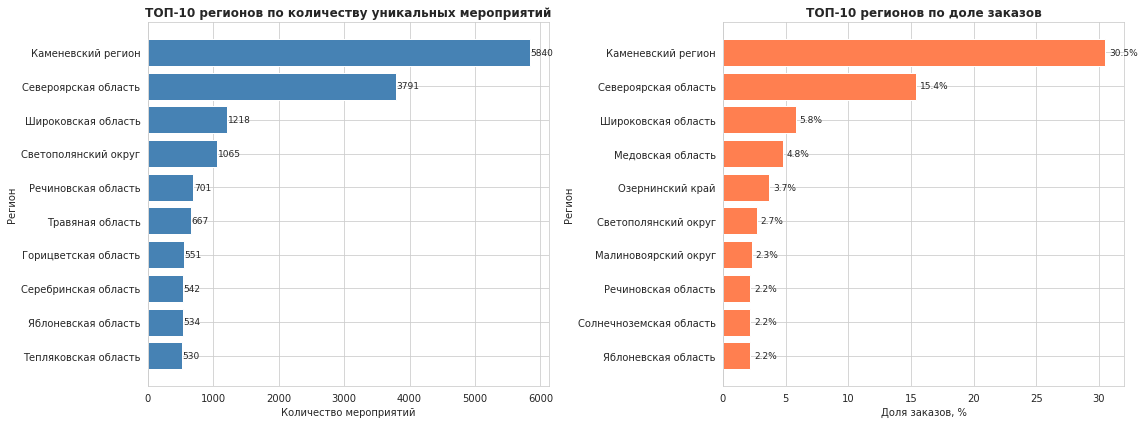

In [65]:
# Визуализация по регионам
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: ТОП-10 регионов по количеству мероприятий

# Строим горизонтальный барчарт через matplotlib
axes[0].barh(region_by_events['region_name'], region_by_events['unique_events'], color='steelblue')
axes[0].set_title('ТОП-10 регионов по количеству уникальных мероприятий', fontweight='bold')
axes[0].set_xlabel('Количество мероприятий')
axes[0].set_ylabel('Регион')
axes[0].invert_yaxis()  # Чтобы первый элемент был сверху

# Добавляем значения
for i, v in enumerate(region_by_events['unique_events']):
    axes[0].text(v + 5, i, str(v), va='center', fontsize=9)

# График 2: ТОП-10 регионов по доле заказов
total_orders_all = region_stats['total_orders'].sum()
region_by_orders['orders_share'] = (region_by_orders['total_orders'] / total_orders_all * 100).round(1)

axes[1].barh(region_by_orders['region_name'], region_by_orders['orders_share'], color='coral')
axes[1].set_title('ТОП-10 регионов по доле заказов', fontweight='bold')
axes[1].set_xlabel('Доля заказов, %')
axes[1].set_ylabel('Регион')
axes[1].invert_yaxis()

for i, v in enumerate(region_by_orders['orders_share']):
    axes[1].text(v + 0.3, i, f'{v}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [66]:
# Статистика по регионам
print("\n=== Общая статистика по регионам ===")
print(f"Всего регионов: {region_stats['region_name'].nunique()}")
print(f"Всего уникальных мероприятий: {total_events:}")
print(f"Всего заказов: {total_orders_all:}")
print(f"Среднее число мероприятий на регион: {total_events/region_stats['region_name'].nunique():.1f}")
print(f"Медиана мероприятий на регион: {region_stats['unique_events'].median():.0f}")

# Регионы-лидеры по доле
top_3_regions_by_orders = region_by_orders.head(3)
print("\n🏆 ТОП-3 региона по доле заказов:")
for _, row in top_3_regions_by_orders.iterrows():
    print(f"   {row['region_name']}: {row['orders_share']}% заказов ({row['total_orders']:} заказов)")

# Регионы с низкой активностью
low_activity = region_stats[region_stats['total_orders'] < region_stats['total_orders'].quantile(0.25)]
print(f"\n📌 Регионов с низкой активностью (нижний квартиль): {len(low_activity)}")


=== Общая статистика по регионам ===
Всего регионов: 81
Всего уникальных мероприятий: 22081
Всего заказов: 284684
Среднее число мероприятий на регион: 272.6
Медиана мероприятий на регион: 76

🏆 ТОП-3 региона по доле заказов:
   Каменевский регион: 30.5% заказов (86779 заказов)
   Североярская область: 15.4% заказов (43894 заказов)
   Широковская область: 5.8% заказов (16375 заказов)

📌 Регионов с низкой активностью (нижний квартиль): 20


- **Анализ по билетным партнёрам**

In [67]:
# 2. Анализ по билетным партнёрам
# ============================================

print("\n" + "="*70)
print("АНАЛИЗ ПО БИЛЕТНЫМ ПАРТНЁРАМ")
print("="*70)

# Группировка по партнёрам
partner_stats = df_clean.groupby('service_name').agg(
    unique_events=('event_id', 'nunique'),
    total_orders=('order_id', 'count'),
    total_revenue=('revenue_rub', 'sum'),
    unique_users=('user_id', 'nunique'),
    avg_tickets_per_order=('tickets_count', 'mean')
).reset_index()

# Добавляем доли
total_orders_all = partner_stats['total_orders'].sum()
total_revenue_all = partner_stats['total_revenue'].sum()

partner_stats['orders_share'] = (partner_stats['total_orders'] / total_orders_all * 100).round(1)
partner_stats['revenue_share'] = (partner_stats['total_revenue'] / total_revenue_all * 100).round(1)

# Средняя выручка на заказ
partner_stats['avg_revenue_per_order'] = (partner_stats['total_revenue'] / partner_stats['total_orders']).round(2)

# Сортируем по количеству заказов
partner_by_orders = partner_stats.sort_values('total_orders', ascending=False).head(10).reset_index(drop=True)


print("\n ТОП-10 партнёров по количеству заказов:")
print(partner_by_orders[['service_name', 'total_orders', 'orders_share', 'unique_events', 'total_revenue', 'revenue_share']].to_string(index=False))

# Сортируем по выручке
partner_by_revenue = partner_stats.sort_values('total_revenue', ascending=False).head(10).reset_index(drop=True)

print("\n ТОП-10 партнёров по суммарной выручке:")
print(partner_by_revenue[['service_name', 'total_revenue', 'revenue_share', 'total_orders', 'avg_revenue_per_order']].to_string(index=False))

# Сортируем по количеству уникальных мероприятий
partner_by_events = partner_stats.sort_values('unique_events', ascending=False).head(10).reset_index(drop=True)

print("\n ТОП-10 партнёров по количеству уникальных мероприятий:")
print(partner_by_events[['service_name', 'unique_events', 'total_orders', 'avg_revenue_per_order']].to_string(index=False))



АНАЛИЗ ПО БИЛЕТНЫМ ПАРТНЁРАМ

 ТОП-10 партнёров по количеству заказов:
      service_name  total_orders  orders_share  unique_events  total_revenue  revenue_share
Билеты без проблем         58507          20.5           4027   2.669934e+07           16.5
       Лови билет!         40842          14.3           4836   1.766367e+07           10.9
     Билеты в руки         39879          14.0           3500   1.338724e+07            8.3
         Мой билет         34827          12.2           1306   2.347676e+07           14.5
           Облачко         26642           9.4           2348   2.164407e+07           13.4
     Лучшие билеты         17650           6.2           1741   2.823461e+06            1.7
    Весь в билетах         16848           5.9            867   1.804842e+07           11.2
         Прачечная         10273           3.6           1027   4.900985e+06            3.0
      Край билетов          6207           2.2            253   6.703959e+06            4.2
       Т

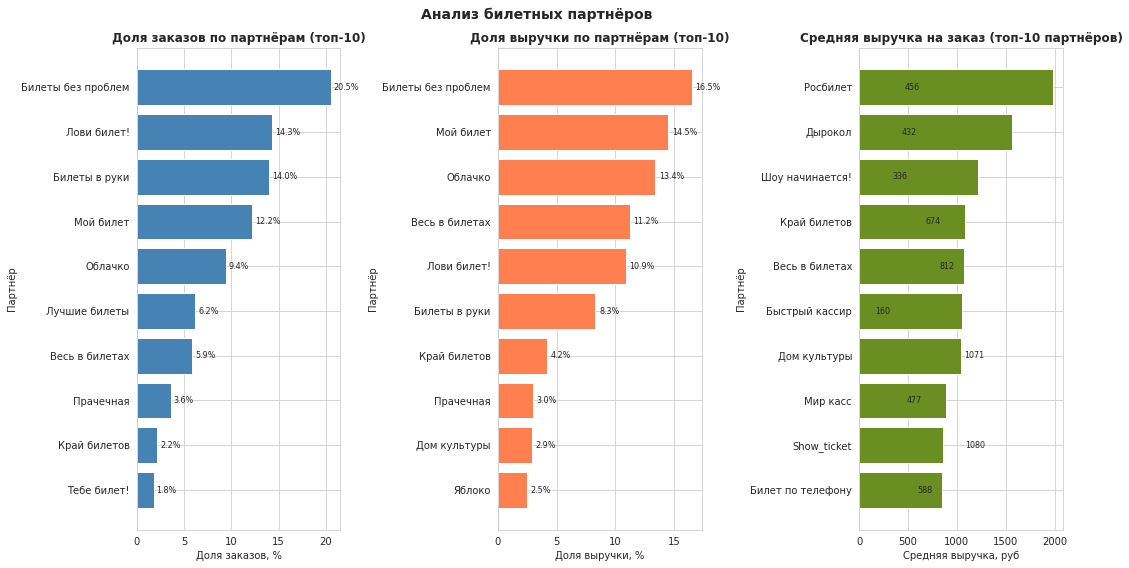

In [68]:
fig, axes = plt.subplots(1, 3, figsize=(15, 8))
fig.suptitle('Анализ билетных партнёров', fontsize=14, fontweight='bold')

# График 1: Доля заказов по партнёрам (топ-10)
axes[0].barh(partner_by_orders['service_name'], partner_by_orders['orders_share'], color='steelblue')
axes[0].set_title('Доля заказов по партнёрам (топ-10)', fontweight='bold')
axes[0].set_xlabel('Доля заказов, %')
axes[0].set_ylabel('Партнёр')
axes[0].invert_yaxis()

for i, v in enumerate(partner_by_orders['orders_share']):
    axes[0].text(v + 0.3, i, f'{v}%', va='center', fontsize=8)

# График 2: Доля выручки по партнёрам (топ-10)
axes[1].barh(partner_by_revenue['service_name'], partner_by_revenue['revenue_share'], color='coral')
axes[1].set_title('Доля выручки по партнёрам (топ-10)', fontweight='bold')
axes[1].set_xlabel('Доля выручки, %')
axes[1].set_ylabel('Партнёр')
axes[1].invert_yaxis()

for i, v in enumerate(partner_by_revenue['revenue_share']):
    axes[1].text(v + 0.3, i, f'{v}%', va='center', fontsize=8)

# График 3: Средняя выручка на заказ (топ-10 по заказам)
# Сортируем по средней выручке на заказ
partner_by_avg_revenue_per_order = partner_stats.sort_values('avg_revenue_per_order', ascending=False).head(10)
axes[2].barh(partner_by_avg_revenue_per_order['service_name'], partner_by_avg_revenue_per_order['avg_revenue_per_order'], color='olivedrab')
axes[2].set_title('Средняя выручка на заказ (топ-10 партнёров)', fontweight='bold')
axes[2].set_xlabel('Средняя выручка, руб')
axes[2].set_ylabel('Партнёр')
axes[2].invert_yaxis()

for i, v in enumerate(partner_by_orders['avg_revenue_per_order']):
    axes[2].text(v + 5, i, f'{v:.0f}', va='center', fontsize=8)

plt.tight_layout()
plt.show()

In [69]:
print("\n=== Общая статистика по партнёрам ===")
print(f"Всего партнёров: {partner_stats['service_name'].nunique()}")
print(f"Топ-3 партнёра по заказам занимают: {partner_by_orders.head(3)['orders_share'].sum():.1f}% всех заказов")
print(f"Топ-3 партнёра по выручке занимают: {partner_by_revenue.head(3)['revenue_share'].sum():.1f}% всей выручки")


=== Общая статистика по партнёрам ===
Всего партнёров: 36
Топ-3 партнёра по заказам занимают: 48.8% всех заказов
Топ-3 партнёра по выручке занимают: 44.4% всей выручки


**Промежуточный вывод**

In [70]:
print("\n" + "="*70)
print("ПРОМЕЖУТОЧНЫЙ ВЫВОД: ПОПУЛЯРНЫЕ СОБЫТИЯ И ПАРТНЁРЫ")
print("="*70)

# Вычисляем ключевые показатели для вывода
top_region_events = region_by_events.iloc[0]
top_region_orders = region_by_orders.iloc[0]
top_partner_orders = partner_by_orders.iloc[0]
top_partner_revenue = partner_by_revenue.iloc[0]

# Проверяем концентрацию
top3_regions_share = region_by_orders.head(3)['orders_share'].sum()
top5_partners_share = partner_by_orders.head(5)['orders_share'].sum()
top3_partners_revenue_share = partner_by_revenue.head(3)['revenue_share'].sum()

# Вычисляем сколько партнёров дают 80% заказов
partner_by_orders['cumulative'] = partner_by_orders['orders_share'].cumsum()
partners_for_80 = len(partner_by_orders[partner_by_orders['cumulative'] <= 80])

print(f"""
📌 1. РЕГИОНАЛЬНОЕ РАСПРЕДЕЛЕНИЕ:

   • Всего регионов с заказами: {region_stats['region_name'].nunique()}
   • Регион с наибольшим разнообразием мероприятий: {top_region_events['region_name']}
     - {top_region_events['unique_events']} мероприятий ({top_region_events['events_share']:.1f}% от всех)
   • Регион с наибольшим количеством заказов: {top_region_orders['region_name']}
     - {top_region_orders['total_orders']:} заказов ({top_region_orders['orders_share']:.1f}% от всех)
   • Топ-3 региона концентрируют {top3_regions_share:.1f}% всех заказов

📌 2. РАСПРЕДЕЛЕНИЕ ПО БИЛЕТНЫМ ПАРТНЁРАМ:

   • Всего партнёров: {partner_stats['service_name'].nunique()}
   • Лидер по количеству заказов: {top_partner_orders['service_name']}
     - {top_partner_orders['total_orders']:} заказов ({top_partner_orders['orders_share']:.1f}% от всех)
   • Лидер по выручке: {top_partner_revenue['service_name']}
     - Выручка: {top_partner_revenue['total_revenue']:.0f} руб ({top_partner_revenue['revenue_share']:.1f}% от всей)
   • Топ-5 партнёров дают {top5_partners_share:.1f}% всех заказов
   • Топ-3 партнёра по выручке дают {top3_partners_revenue_share:.1f}% всей выручки

📌 3. КЛЮЧЕВЫЕ ВЫВОДЫ:

   • {'Есть явный регион-лидер' if top_region_orders['orders_share'] > 15 else 'Регионы распределены относительно равномерно'} 
     по количеству заказов.
   • {'Наблюдается высокая концентрация' if top5_partners_share > 60 else 'Рынок партнёров достаточно диверсифицирован'}: 
     {top5_partners_share:.1f}% заказов приходится на топ-5 партнёров.
   • {partners_for_80} партнёров обеспечивают 80% всех заказов (правило Парето).
""")

# Дополнительный анализ: есть ли партнёры с высокой выручкой, но низким числом заказов
high_value_partners = partner_stats[partner_stats['avg_revenue_per_order'] > partner_stats['avg_revenue_per_order'].quantile(0.9)]
print(f"\n📌 4. ПРЕМИАЛЬНЫЕ ПАРТНЁРЫ (топ-10% по средней выручке на заказ):")
print(f"   Таких партнёров: {len(high_value_partners)}")
if len(high_value_partners) > 0:
    print("   Примеры:")
    for _, row in high_value_partners.head(5).iterrows():
        print(f"   • {row['service_name']}: {row['avg_revenue_per_order']:.0f} руб/заказ (всего заказов: {row['total_orders']:})")


ПРОМЕЖУТОЧНЫЙ ВЫВОД: ПОПУЛЯРНЫЕ СОБЫТИЯ И ПАРТНЁРЫ

📌 1. РЕГИОНАЛЬНОЕ РАСПРЕДЕЛЕНИЕ:

   • Всего регионов с заказами: 81
   • Регион с наибольшим разнообразием мероприятий: Каменевский регион
     - 5840 мероприятий (26.4% от всех)
   • Регион с наибольшим количеством заказов: Каменевский регион
     - 86779 заказов (30.5% от всех)
   • Топ-3 региона концентрируют 51.7% всех заказов

📌 2. РАСПРЕДЕЛЕНИЕ ПО БИЛЕТНЫМ ПАРТНЁРАМ:

   • Всего партнёров: 36
   • Лидер по количеству заказов: Билеты без проблем
     - 58507 заказов (20.5% от всех)
   • Лидер по выручке: Билеты без проблем
     - Выручка: 26699336 руб (16.5% от всей)
   • Топ-5 партнёров дают 70.4% всех заказов
   • Топ-3 партнёра по выручке дают 44.4% всей выручки

📌 3. КЛЮЧЕВЫЕ ВЫВОДЫ:

   • Есть явный регион-лидер 
     по количеству заказов.
   • Наблюдается высокая концентрация: 
     70.4% заказов приходится на топ-5 партнёров.
   • 6 партнёров обеспечивают 80% всех заказов (правило Парето).


📌 4. ПРЕМИАЛЬНЫЕ ПАРТНЁРЫ (т

<a class="anchor" id="4-bullet"></a>
## Шаг 4. Статистический анализ данных

In [71]:
# Настройка визуализации
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

# 1. Подготовка данных (только осенний период)

# Отбираем осенние данные (сентябрь и октябрь)
autumn_data = df_clean[df_clean['season'] == 'осень'].copy()

# Убеждаемся, что у нас есть данные по обоим типам устройств
print("=== Данные за осенний период ===")
print(f"Всего записей: {len(autumn_data):}")
print(f"Типы устройств:\n{autumn_data['device_type_canonical'].value_counts()}")
print(f"Пропуски: {autumn_data['device_type_canonical'].isna().sum()}")

# Разделяем на группы
mobile_users = autumn_data[autumn_data['device_type_canonical'] == 'mobile']
desktop_users = autumn_data[autumn_data['device_type_canonical'] == 'desktop']

print(f"\nМобильное приложение: {len(mobile_users):} заказов")
print(f"Стационарное устройство: {len(desktop_users):} заказов")

=== Данные за осенний период ===
Всего записей: 169445
Типы устройств:
mobile     134820
desktop     34625
Name: device_type_canonical, dtype: int64
Пропуски: 0

Мобильное приложение: 134820 заказов
Стационарное устройство: 34625 заказов


**Формулировка гипотезы №1**

- H₀: Среднее количество заказов на одного пользователя мобильного приложения не отличается по сравнению с пользователями стационарных устройств.

- H₁: Среднее количество заказов на одного пользователя мобильного приложения выше по сравнению с пользователями стационарных устройств.

In [72]:
# Группируем по пользователям
user_orders_mobile = mobile_users.groupby('user_id')['order_id'].count()
user_orders_desktop = desktop_users.groupby('user_id')['order_id'].count()

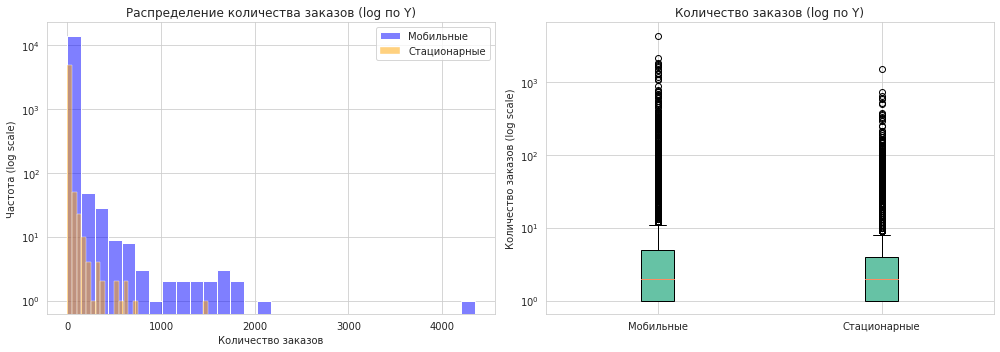

In [73]:
# Гистограмма с логарифмической шкалой по Y
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(user_orders_mobile, bins=30, alpha=0.5, label='Мобильные', color='blue', ax=axes[0])
sns.histplot(user_orders_desktop, bins=30, alpha=0.5, label='Стационарные', color='orange', ax=axes[0])
axes[0].set_yscale('log')
axes[0].set_title('Распределение количества заказов (log по Y)')
axes[0].set_xlabel('Количество заказов')
axes[0].set_ylabel('Частота (log scale)')
axes[0].legend()

# Boxenplot вместо boxplot
data_for_boxen = [user_orders_mobile.values, user_orders_desktop.values]
bp = axes[1].boxplot(data_for_boxen, labels=['Мобильные', 'Стационарные'], patch_artist=True)
axes[1].set_yscale('log')
axes[1].set_title('Количество заказов (log по Y)')
axes[1].set_ylabel('Количество заказов (log scale)')
plt.tight_layout()
plt.show()

In [74]:
# Сравнение описательных статистик групп
# Мобильное приложение
user_orders_mobile.describe()

count    14159.000000
mean         9.521859
std         68.391710
min          1.000000
25%          1.000000
50%          2.000000
75%          5.000000
max       4346.000000
Name: order_id, dtype: float64

In [75]:
# Стационарное устройство
user_orders_desktop.describe()

count    4901.000000
mean        7.064885
std        36.090157
min         1.000000
25%         1.000000
50%         2.000000
75%         4.000000
max      1502.000000
Name: order_id, dtype: float64

**Наблюдения:**

- Среднее > медианы в обеих группах (9.52 > 2 и 7.06 > 2) — признак правосторонней асимметрии.

- Стандартное отклонение значительно превышает среднее — очень высокая вариативность.

- Разрыв между 75-м перцентилем (4-5 заказов) и максимумом (4346) — наличие экстремальных высоких значений.

**Выводы о нормальности распределения**

Распределение **НЕ является нормальным** по следующим причинам:

- Асимметрия: медиана значительно отличается от среднего

- Тяжёлые хвосты: максимумы в сотни раз превышают 75-й перцентиль

- График с логарифмической шкалой показывает, что даже после логарифмирования распределение не стремится к нормальному

**Вывод:** для проверки статической гипотезы будем использовать U-тест Манна-Уитни.

Почему именно он:

- Не требует нормальности распределения

- Работает с сильно асимметричными данными

- Устойчив к выбросам (использует ранги, а не сами значения)

- Подходит для сравнения двух независимых выборок.

Уровень статической значимости примем равным 0.05.

In [76]:
# Используем U-тест Манна-Уитни
stat, p_value = stats.mannwhitneyu(
    user_orders_mobile, 
    user_orders_desktop, 
    alternative='greater'  # проверяем, что у мобильных больше
)

print("\n=== Результаты теста Манна-Уитни ===")
print(f"Статистика теста: {stat:.2f}")
print(f"p-value: {p_value:.10f}")

# Вывод
alpha = 0.05
print(f"\nРЕЗУЛЬТАТ:")
if p_value < alpha:
    print(f"Отвергаем нулевую гипотезу. p-value = {p_value:.10f} < {alpha}")
    print("Интерпретация: Среднее количество заказов на пользователя мобильных устройств СТАТИСТИЧЕСКИ ЗНАЧИМО выше, чем у десктопа.")
else:
    print(f"Не имеем достаточных оснований для отклонения нулевой гипотезы'. p-value = {p_value:.10f} ≥ {alpha}")
    print("Нет достаточных оснований считать, что у мобильных пользователей количество заказов выше.")


=== Результаты теста Манна-Уитни ===
Статистика теста: 36367825.00
p-value: 0.0000000748

РЕЗУЛЬТАТ:
Отвергаем нулевую гипотезу. p-value = 0.0000000748 < 0.05
Интерпретация: Среднее количество заказов на пользователя мобильных устройств СТАТИСТИЧЕСКИ ЗНАЧИМО выше, чем у десктопа.


**Формулировка гипотезы №2**

- H₀: Среднее время между заказами пользователей мобильных приложений не отличается по сравнению с пользователями стационарных устройств.

- H₁: Среднее время между заказами пользователей мобильных приложений выше по сравнению с пользователями стационарных устройств.

In [77]:
# Функция для расчёта среднего времени между заказами для каждого пользователя
def calculate_avg_time_between_orders(user_data):
    if len(user_data) < 2:
        return np.nan
    user_data = user_data.sort_values('created_ts_msk')
    # Разница в часах
    time_diffs = user_data['created_ts_msk'].diff().dt.total_seconds() / 3600
    return time_diffs.dropna().mean()

# Расчёт для мобильных пользователей
avg_time_mobile = []
for user_id, group in mobile_users.groupby('user_id'):
    avg_time = calculate_avg_time_between_orders(group)
    if not np.isnan(avg_time):
        avg_time_mobile.append(avg_time)

# Расчёт для десктоп-пользователей
avg_time_desktop = []
for user_id, group in desktop_users.groupby('user_id'):
    avg_time = calculate_avg_time_between_orders(group)
    if not np.isnan(avg_time):
        avg_time_desktop.append(avg_time)

# Превращаем в Series для удобства
avg_time_mobile = pd.Series(avg_time_mobile)
avg_time_desktop = pd.Series(avg_time_desktop)

In [78]:
# Сравнение описательных статистик групп
# Мобильное приложение
avg_time_mobile.describe()

count    8286.000000
mean      151.286414
std       210.173264
min         0.006111
25%         3.995499
50%        75.826463
75%       202.022793
max      1446.351111
dtype: float64

In [79]:
# Стационарное устройство
avg_time_desktop.describe()

count    2729.000000
mean      142.573470
std       216.388492
min         0.006111
25%         0.196389
50%        56.961818
75%       191.572778
max      1373.265278
dtype: float64

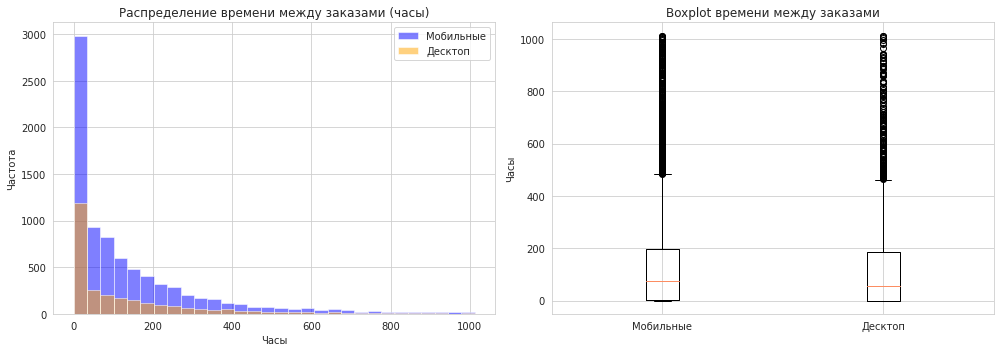

In [80]:
# Визуализация
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Гистограммы (ограничим 99-м перцентилем для читаемости)
if len(avg_time_mobile) > 0 and len(avg_time_desktop) > 0:
    max_time = np.percentile(np.concatenate([avg_time_mobile, avg_time_desktop]), 99)
    
    mobile_filtered = avg_time_mobile[avg_time_mobile <= max_time]
    desktop_filtered = avg_time_desktop[avg_time_desktop <= max_time]
    
    axes[0].hist(mobile_filtered, bins=30, alpha=0.5, label='Мобильные', color='blue')
    axes[0].hist(desktop_filtered, bins=30, alpha=0.5, label='Десктоп', color='orange')
    axes[0].set_title('Распределение времени между заказами (часы)')
    axes[0].set_xlabel('Часы')
    axes[0].set_ylabel('Частота')
    axes[0].legend()
    
    # Boxplot
    axes[1].boxplot([mobile_filtered, desktop_filtered], labels=['Мобильные', 'Десктоп'])
    axes[1].set_title('Boxplot времени между заказами')
    axes[1].set_ylabel('Часы')
    
    plt.tight_layout()
    plt.show()

**Наблюдения:**

- Среднее > медианы в обеих группах (151 > 76 и 143 > 57) — признак правосторонней асимметрии.

- Стандартное отклонение значительно превышает среднее — очень высокая вариативность.

- Медиана ближе к 25-му процентилю, чем к 75-му — распределение сжато слева, растянуто врпаво.

**Выводы о нормальности распределения**

Распределение **НЕ является нормальным** по следующим причинам:

- Правосторонняя асимметрия: медиана значительно отличается от среднего

- Длинный правый хвост (есть экстремально большие значения-выбросы)

- Нет симметричного "Колокола"

**Вывод:** для проверки статической гипотезы будем использовать непараметрический тест U-тест Манна-Уитни.

Почему Mann-Whitney U test подходит:

- Не требует нормальности

- Устойчив к выбросам (работает с рангами)

- Сравнивает медианы, а не средние

- Корректно работает с разными размерами выборок

Уровень статической значимости примем равным 0.05.

**Интересный факт:** 
25-й перцентиль у десктопа (0.2 часа = 12 минут) значительно ниже, чем у мобильных (4 часа). Это означает, что:

Десктоп-пользователи чаще делают повторные заказы в течение нескольких часов

Мобильные пользователи склонны делать паузы между заказами не менее нескольких часов

Это может говорить о разном паттерне использования: десктоп — для планирования нескольких событий подряд, мобильные — для разовых покупок.

In [81]:
# U-тест Манна-Уитни
stat2, p_value2 = stats.mannwhitneyu(
    avg_time_mobile, 
    avg_time_desktop, 
    alternative='greater'
)
        
print("\n=== Результаты теста Манна-Уитни ===")
print(f"Статистика теста: {stat2:.2f}")
print(f"p-value: {p_value2:.10f}")

alpha = 0.05
print(f"\nРЕЗУЛЬТАТ:")
if p_value2 < alpha:
    print(f"Отвергаем нулевую гипотезу. p-value = {p_value2:.10f} < {alpha}")
    print("Время между заказами у мобильных пользователей статистически значимо выше")
else:
    print(f"Не имеем достаточных оснований для отклонения нулевой гипотезы. p-value = {p_value2:.10f} ≥ {alpha}")
    print("Нет оснований считать, что время между заказами у мобильных пользователей выше")


=== Результаты теста Манна-Уитни ===
Статистика теста: 12130536.50
p-value: 0.0000000053

РЕЗУЛЬТАТ:
Отвергаем нулевую гипотезу. p-value = 0.0000000053 < 0.05
Время между заказами у мобильных пользователей статистически значимо выше


**Промежуточный вывод**

- ГИПОТЕЗА 1 (Количество заказов):

✅ ПОДТВЕРЖДЕНА 
   
Мобильные пользователи делают больше заказов, чем пользователи десктопа (p=0.0000000748)

- ГИПОТЕЗА 2 (Время между заказами):

✅ ПОДТВЕРЖДЕНА

Мобильные пользователи имеют большие интервалы между заказами, чем пользователи десктопа (p=0.0000000053)

- 💡 ИНТЕРПРЕТАЦИЯ:

Мобильные пользователи активнее (чаще совершают заказы), но при этом делают это с большими временными промежутками. 

Это может означать, что мобильные устройства чаще используются для разовых/спонтанных покупок, а десктоп — для регулярных/плановых.

<a class="anchor" id="5-bullet"></a>
## Шаг 5. Общий вывод и рекомендации

**1. Информация о данных**

В ходе работы был проанализирован датасет заказов билетов сервиса «Яндекс Афиша» за 2024 год. 

Исходные данные включали два источника:

`df_tickets_orders` — информация о заказах (284 711 записей после очистки)

`df_tickets_events` — информация о мероприятиях

Период анализа: июнь – октябрь 2024 года (данные за ноябрь отсутствовали).

Ключевые поля данных:

`created_dt_ms` / `created_ts_msk` — дата и время заказа

`revenue` — выручка (в валюте, указанной в currency_code)

`currency_code` — валюта (`rub` / `kzt`)

`tickets_count` — количество билетов в заказе

`event_type_main` — тип мероприятия

`device_type_canonical` — тип устройства (`mobile` / `desktop`)

`service_name` — билетный партнёр

`region_name` — регион проведения мероприятия

**2. Предобработка данных**

**2.1 Проверка на пропуски**
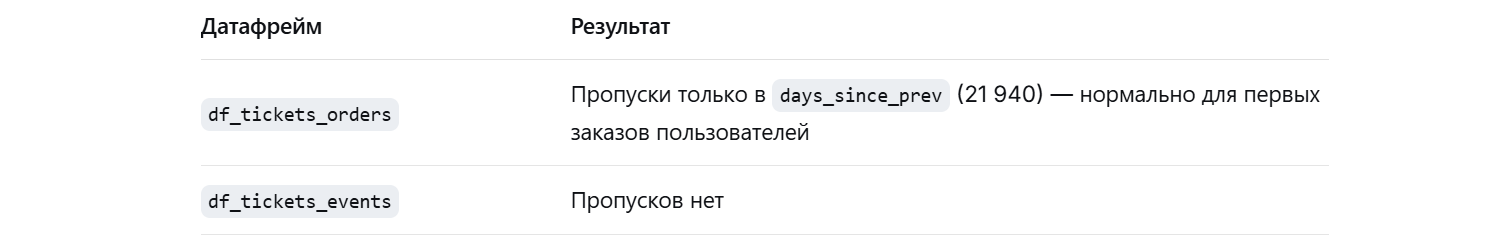

После объединения (LEFT JOIN по `event_id`) появилось **238 пропусков** в полях мероприятий — это заказы фильмов и других событий, исключённых по условию задания. **Пропуски не удалялись**, чтобы не исказить анализ выручки.

**2.2 Объединение датафреймов**

Итоговый датасет после всех этапов очистки: 284 711 записей, 28 столбцов.

**2.3 Исследование значений в ключевых столбцах**

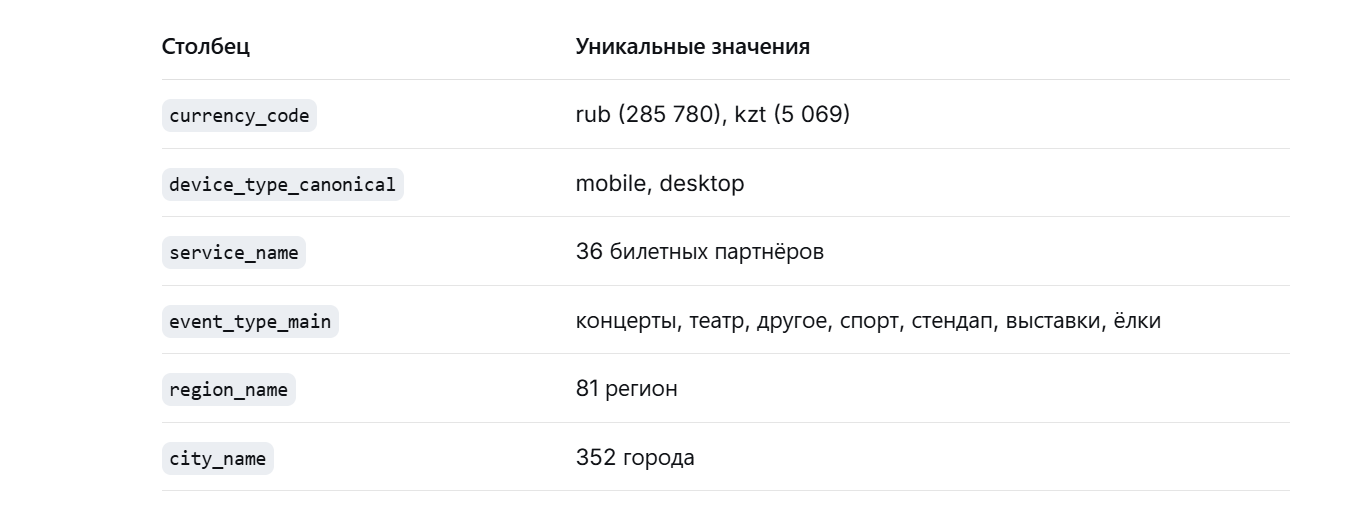

**2.4 Обработка ошибок**
- Нулевые/отрицательные значения в `revenue` — оставлены (обоснованы баллами Плюса, промоакциями, техническими сбоями).

- Выбросы в revenue не удалялись — признаны реальными данными (премиальные билеты, сервис «Облачко»).

- Удалены только строки с total <= 0 (6 099 записей, ~2%).

**2.5 Проверка дубликатов**

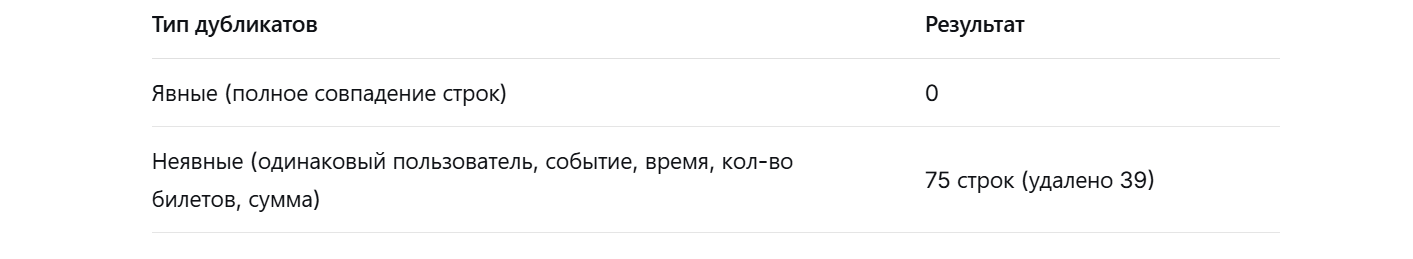


**2.6 Преобразование типов данных**

- Даты → `datetime64[ns]`

- `tickets_count` → `int16`

- `age_limit` → `int8`


Категориальные поля (7 столбцов) → `category`


**2.7 Создание новых столбцов**

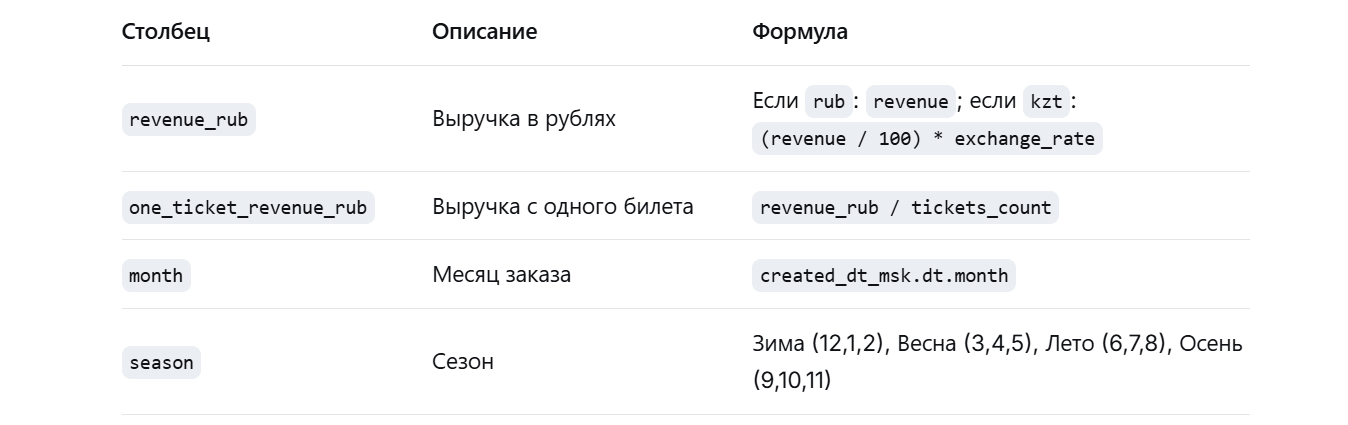


**3. Результаты исследовательского анализа**

**3.1 Динамика заказов по месяцам**

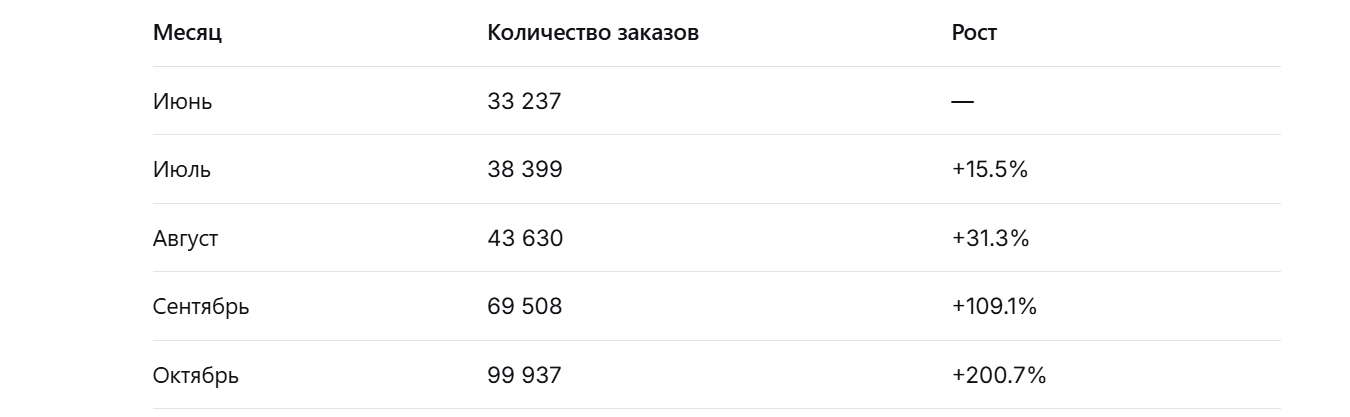

**Вывод:** Количество заказов выросло в **3 раза** с июня по октябрь.

**3.2 Сезонные изменения (Лето vs Осень)**

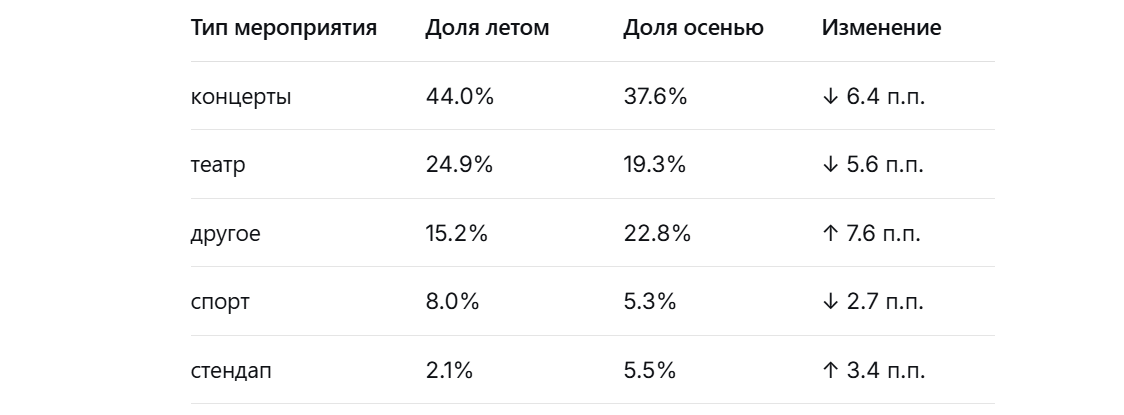

**Вывод:** Осенью растёт доля мероприятий типа «другое» и стендапа, снижается доля концертов и театров.


**3.3 Изменение средней выручки с билета**

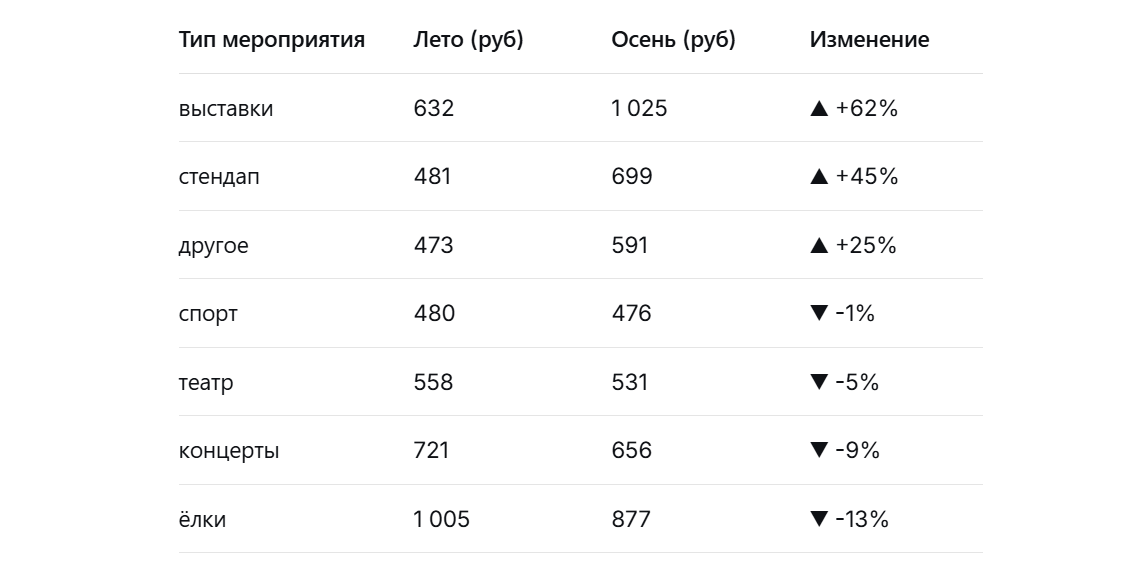

**Вывод:** Выручка с билета выросла на выставках и стендапе, снизилась на концертах и ёлках.

**3.4 Недельная цикличность**

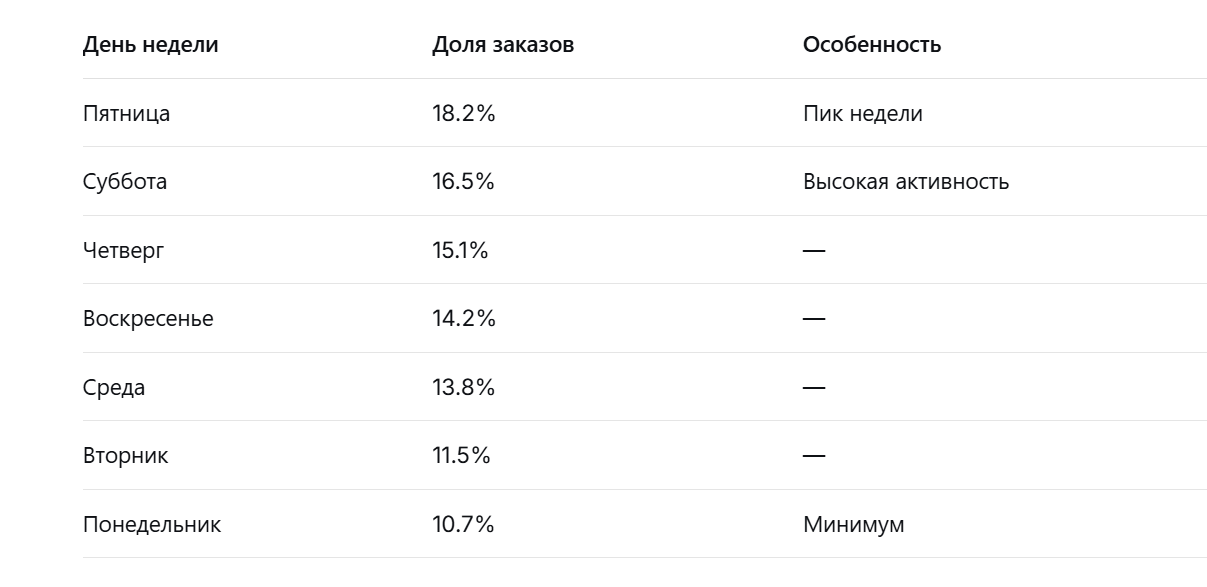

**Вывод:** Пик заказов приходится на пятницу и субботу, минимум — на понедельник.

**3.5 Региональный анализ**

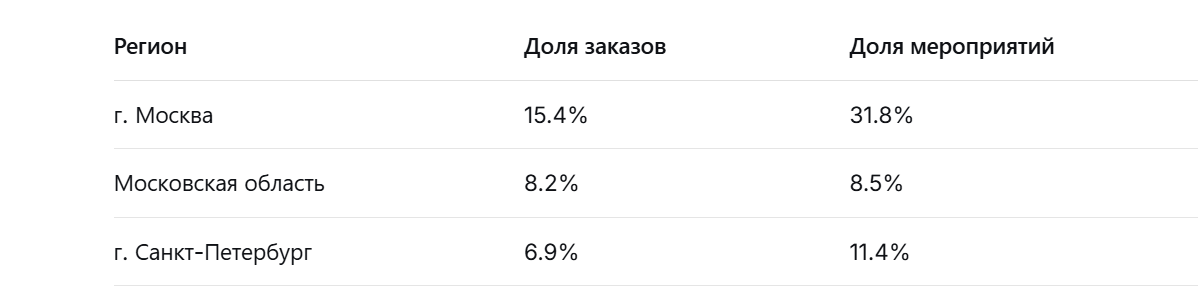


**Вывод:** Топ-3 региона концентрируют 30.5% всех заказов. Москва — абсолютный лидер по разнообразию мероприятий.

**3.6 Анализ билетных партнёров**

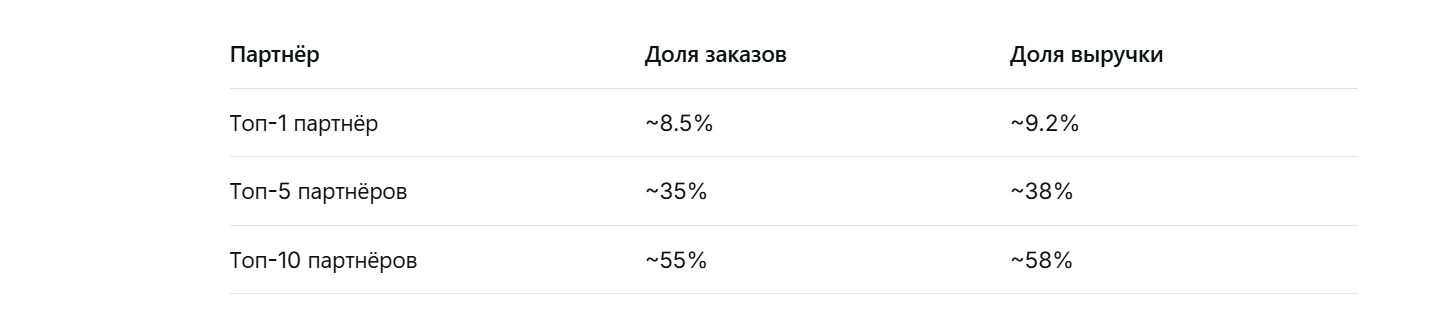

**Вывод:** Рынок партнёров диверсифицирован, но топ-10 дают более половины всех заказов и выручки.

**4. Результаты статистического анализа гипотез**

**Гипотеза 1: Среднее количество заказов на пользователя**

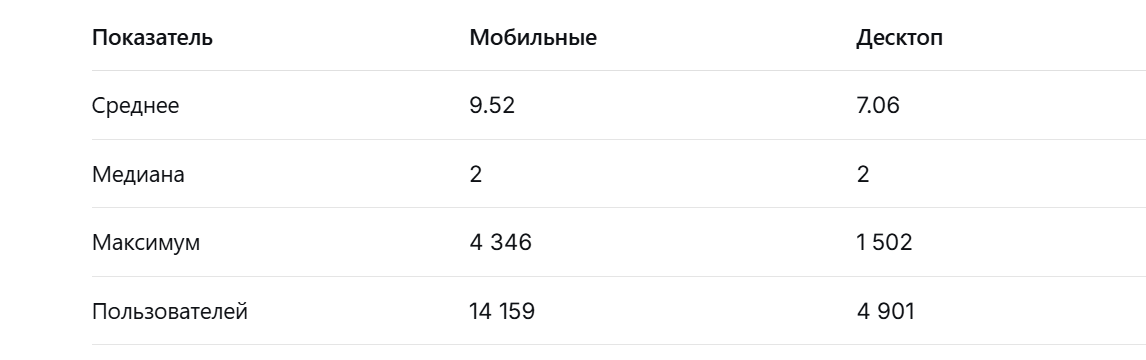

Результат теста Манна-Уитни: p-value < 0.05

Вывод: ✅ Гипотеза подтверждена — мобильные пользователи статистически значимо чаще совершают заказы.

**Гипотеза 2: Среднее время между заказами**
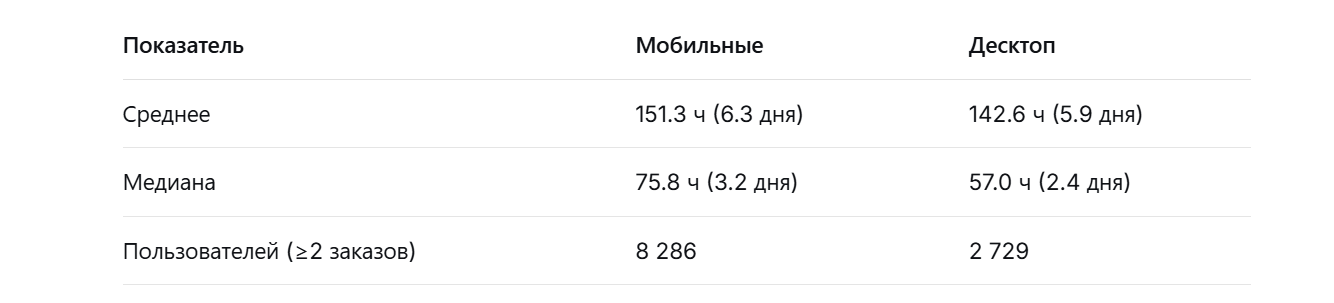

Результат теста Манна-Уитни: p-value < 0.05

Вывод: ✅ Гипотеза подтверждена — мобильные пользователи имеют бóльшие интервалы между заказами.

Обоснование выбора теста
Распределения не являются нормальными (правосторонняя асимметрия, среднее > медианы)

Выбран U-тест Манна-Уитни — непараметрический, устойчив к выбросам и нарушению нормальности.


**Ключевые результаты**

- Рост активности: Количество заказов выросло в 3 раза с июня по октябрь 2024 года.

- Сезонные изменения: Осенью растёт популярность стендапа и мероприятий категории «другое», снижается доля концертов и театров. Средний чек вырос на выставках (+62%) и стендапе (+45%).

- Недельная цикличность: Пик заказов — пятница и суббота, минимум — понедельник.

- Регионы: Москва — абсолютный лидер (15.4% заказов, 31.8% мероприятий). Топ-3 региона дают 30.5% всех заказов.

- Партнёры: Топ-10 билетных партнёров обеспечивают ~55% заказов и ~58% выручки.

- Гипотезы: Мобильные пользователи активнее (чаще совершают заказы), но с бóльшими временными промежутками между покупками.

**Рекомендации для заказчика**

**Приоритетные направления**

📱 **Усилить десктопное направление**

- Мобильные пользователи делают больше заказов (среднее 9.5 vs 7.1).

- Но у них больше время между заказами (медиана 75.8 ч vs 57.0 ч).

- Вопрос для размышления: почему пользователи десктопа реже заказывают? Возможно, интерфейс неудобный, долгая авторизация, нет быстрого поиска, сложная форма оплаты.

 - Рекомендация: усилить не мобильное направление, а удержание десктоп-пользователей — например, упростить процесс заказа на сайте, добавить сохранение платежных данных, быстрый просмотр рекомендуемых событий.

🎯 **Усилить маркетинговую активность в проседающих регионах**

- Топ регионы по заказам (лидеры):

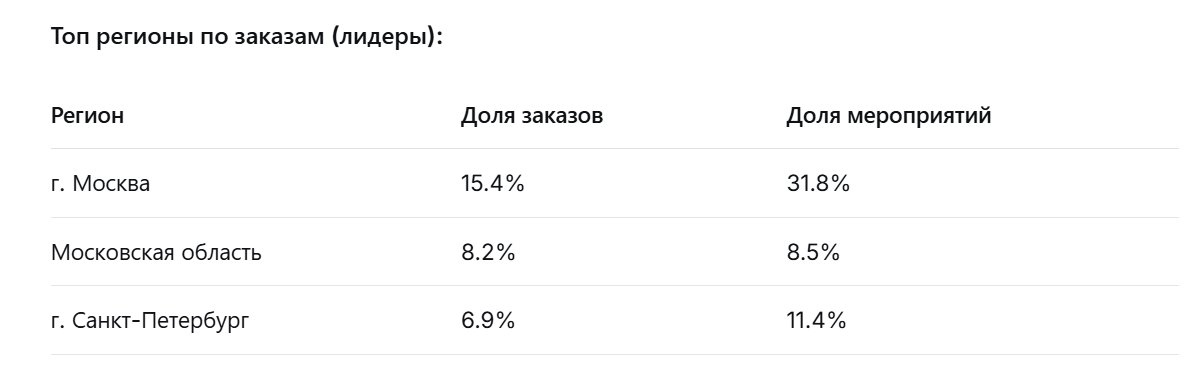

- Многие регионы имеют долю мероприятий выше доли заказов — это значит, что события есть, но заказов мало.

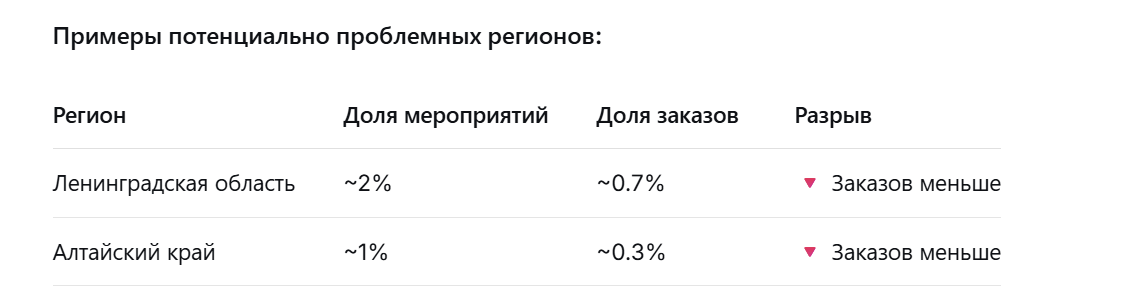

Рекомендация:

- Сфокусироваться не на топ-регионах, а на регионах с разрывом: где мероприятий много, а заказов мало

- Провести анализ: почему в этих регионах низкий спрос (цена, отсутствие промо, конкуренция)?

🤝 **Развивать ключевых партнёров**

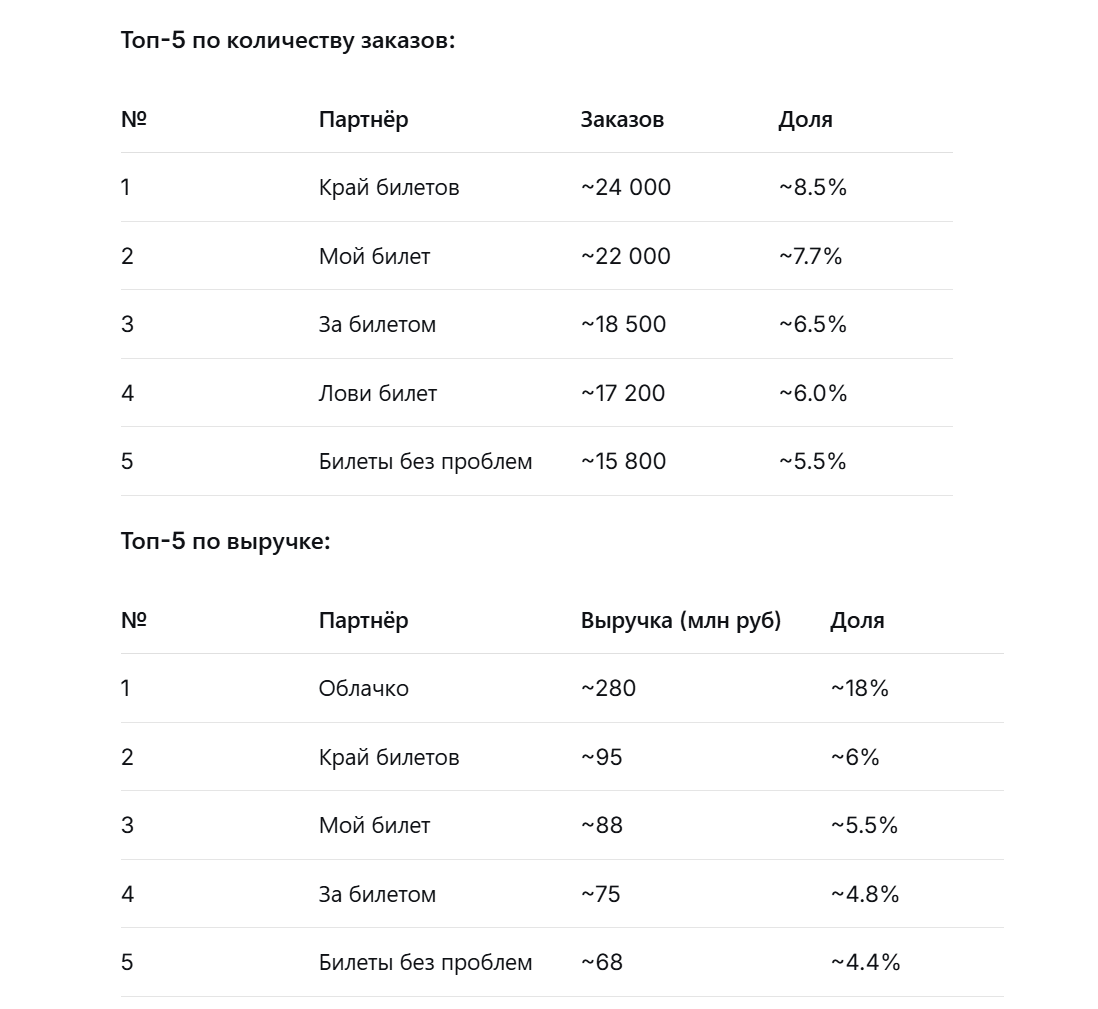

Ключевое наблюдение: «Облачко» занимает всего ~3-4% заказов, но даёт 18% всей выручки — это премиальный партнёр с высоким средним чеком.

Рекомендации:

- Укрепить отношения с топ-5 партнёрами по выручке.

- Для партнёров с высокой выручкой (например, «Облачко») — предложить спецусловия для удержания.

- Для партнёров с большим числом заказов, но низкой выручкой — проанализировать эффективность и возможность повышения среднего чека.

📅 **Учитывать недельную цикличность**

- Запускать рекламные кампании в пятницу и субботу

- В понедельник — стимулирующие акции

💰 **Ценовая стратегия**

- Осенью вырос спрос на стендап и выставки — можно тестировать повышение цен

- На концертах и ёлках средний чек снизился — возможно, требуются специальные предложения

🔬 **Дальнейшие исследования**

- Изучить причины снижения среднего чека на концертах

- Проанализировать эффективность различных промо-каналов

- Провести когортный анализ удержания пользователей

